In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

# DATASET

In [2]:
nps_dataset = pd.read_csv('datasetNPS/1-s2.0-S2468170923000358-mmc1.csv', sep=',', header=0)
print(f'The dataset has {nps_dataset.shape[0]} instances and {nps_dataset.shape[1]} features.')
nps_dataset.head()

The dataset has 891 instances and 602 features.


,Name,1,2,3,4,5,6,7,8,9,...,592,593,594,595,596,597,598,599,600,label
0,1-Phenyl-2-(piperidin-1-yl)butan-1-one,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
1,"2,3-Dimethylethcathinone",0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
2,"2,4-Dimethylethcathinone",0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
3,2-Chloroethcathinone,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
4,2-Ethylethcathinone,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0


In [3]:
nps_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Columns: 602 entries, Name to label
dtypes: float64(579), int64(22), object(1)
memory usage: 4.1+ MB


In [4]:
nps_dataset.describe()

,1,2,3,4,5,6,7,8,9,10,...,592,593,594,595,596,597,598,599,600,label
count,891.0,891.0,891.0,891.0,891.0,891.0,891.0,891.0,891.0,891.0,...,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.0,891.000000
mean,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000034,0.000022,0.000011,0.000011,0.000034,0.000011,0.000011,0.000034,0.0,3.493827
std,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000580,0.000474,0.000335,0.000335,0.000580,0.000335,0.000335,0.000580,0.0,2.137077
min,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.000000
25%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,1.000000
50%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,4.000000
75%,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,5.000000
max,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.010000,0.0,6.000000


In [5]:
print(nps_dataset.isnull().sum(axis=1))

0      0
1      0
2      0
3      0
4      0
      ..
886    0
887    0
888    0
889    0
890    0
Length: 891, dtype: int64


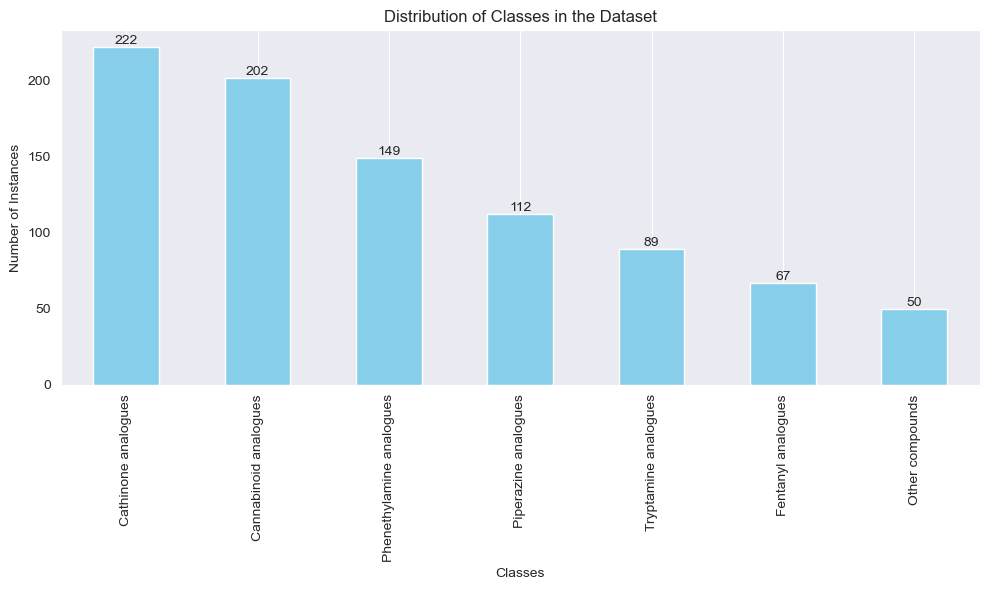

In [6]:
classes = ['Cathinone analogues', 'Cannabinoid analogues',
           'Phenethylamine analogues', 'Piperazine analogues',
           'Tryptamine analogues', 'Fentanyl analogues', 'Other compounds']

distributions = nps_dataset['label'].value_counts()

legends = {
  0: 'Cathinone analogues',
  1: 'Cannabinoid analogues',
  2: 'Phenethylamine analogues',
  3: 'Piperazine analogues',
  4: 'Tryptamine analogues',
  5: 'Fentanyl analogues',
  6: 'Other compounds'
}

plt.figure(figsize=(10, 6))
ax = distributions.plot(kind='bar', color='skyblue')
plt.title('Distribution of Classes in the Dataset')
plt.xlabel('Classes')
plt.ylabel('Number of Instances')
plt.xticks(ticks=range(len(classes)), labels=[legends[i] for i in range(len(classes))], rotation=90)
plt.grid(axis='y')
plt.tight_layout()

for p in ax.patches:
  ax.annotate(str(int(p.get_height())), 
        (p.get_x() + p.get_width() / 2, p.get_height()), 
        ha='center', va='bottom', fontsize=10)

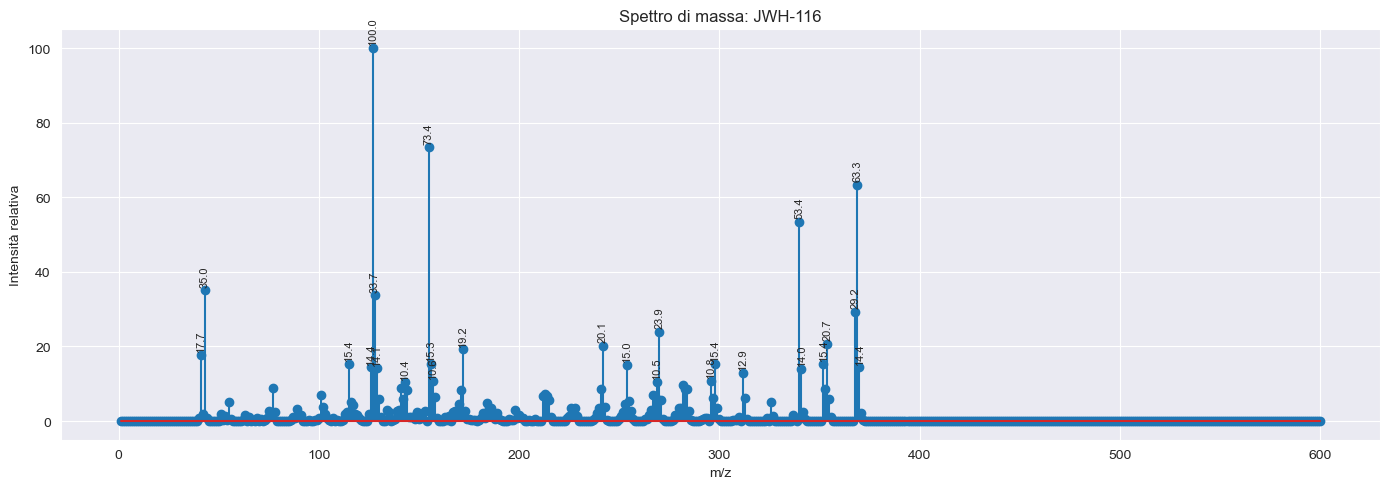

In [7]:
# Nello spettrometro di massa, il segnale sotto m/z 40 è spesso rumore o non rilevante per droghe sintetiche o 
# sostanze organiche complesse. 
#nps_dataset = nps_dataset.drop(columns=nps_dataset.columns[1:41])
#print(f'The dataset has {nps_dataset.shape[0]} instances and {nps_dataset.shape[1]} features after removing noise columns.')

# === spettro di massa ===
nome = "JWH-116"
riga = nps_dataset[nps_dataset.iloc[:, 0] == nome].iloc[0]

spettro = riga[1:-1].astype(float).values 
mz = list(range(1, 601))

# Plot con etichette
plt.figure(figsize=(14, 5))
(markerline, stemlines, baseline) = plt.stem(mz, spettro)
plt.xlabel("m/z")
plt.ylabel("Intensità relativa")
plt.title(f"Spettro di massa: {nome}")
plt.grid(True)

soglia = 10.0
for mzi, intensita in zip(mz, spettro):
    if intensita > soglia:
        plt.text(mzi, intensita + 1, f"{intensita:.1f}", ha='center', va='bottom', fontsize=8, rotation=90)

plt.tight_layout()
plt.show()

# DATA AUGMENTATION

To increase the robustness of the training and compensate
for the limited number of data points, data augmentation was
applied. The abundance values were increased by random
value in the range 0.01 to 9.99%. Such an augmentation
changes the absolute values of m/z intensities without changing
their proportion, i.e. the pattern. This augmentation step was
repeated to obtain four additional data points for each segment

In [8]:
def augment_spectrum(spettro, moltiplicatore=10, percentuale_variabile=0.1):
    augmented = []

    for _ in range(moltiplicatore):
        # Applica variazione casuale ±10%
        variazione = 1 + np.random.uniform(-percentuale_variabile, percentuale_variabile, size=len(spettro))
        spettro_variato = spettro * variazione

        # Rinormalizza: picco massimo = 100
        spettro_normalizzato = spettro_variato / spettro_variato.max() * 100
        augmented.append(spettro_normalizzato)

    return augmented

righe_augmented = []

print(nps_dataset.shape)
print(nps_dataset[1:-1].shape)


for idx, row in nps_dataset.iterrows():
    nome = row["Name"]
    categoria = row["label"]
    spettro = row[1:-1].astype(float).values  # valori m/z 

    # Genera 10 spettrogrammi aumentati
    augmented = augment_spectrum(spettro, moltiplicatore=10)

    for spettro_aug in augmented:
        nuova_riga = [nome] + list(spettro_aug) + [categoria]
        righe_augmented.append(nuova_riga)

colonne = ["Name"] + list(range(1, 601)) + ["label"]
df_augmented = pd.DataFrame(righe_augmented, columns=colonne)
print(f'The augmented dataset has {df_augmented.shape[0]} instances and {df_augmented.shape[1]} features.')
df_augmented


(891, 602)
(889, 602)
The augmented dataset has 8910 instances and 602 features.


,Name,1,2,3,4,5,6,7,8,9,...,592,593,594,595,596,597,598,599,600,label
0,1-Phenyl-2-(piperidin-1-yl)butan-1-one,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
1,1-Phenyl-2-(piperidin-1-yl)butan-1-one,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
2,1-Phenyl-2-(piperidin-1-yl)butan-1-one,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
3,1-Phenyl-2-(piperidin-1-yl)butan-1-one,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
4,1-Phenyl-2-(piperidin-1-yl)butan-1-one,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8905,Digitoxin,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6
8906,Digitoxin,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6
8907,Digitoxin,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6
8908,Digitoxin,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,6


# FEATURE ENGINEERING

Base Peak Mass: Mass-to-charge ratio (m/z) of the peak with the greatest intensity (i.e., “base peak”) 

Base Peak Mass Proximity: m/z difference between base peak and the peak with the nearest m/z value 

Maximum Mass: m/z of the peak with the greatest mass 

Maximum Mass Proximity: m/z difference between maximum-mass peak and the peak with the nearest m/z value 

Number of Peaks: Total number of reported peaks in the spectrum 

Intensity Mean: Mean of all peaks’ intensity values 

Intensity Standard Deviation Standard: deviation of all peaks’ intensity values 

Intensity Density: Maximum intensity divided by number of peaks 
Mass Mean: Mean of all peaks’ m/z 
Mass Standard Deviation: Standard deviation of all peaks’ m/z Mass Density; Maximum mass divided by number of peaks 
Most Frequent Pair Peakwise Mass Difference (PPMD): Most frequent m/z difference among all pairs of peaks 

Mean PPMD: Mean of m/z differences among all pairs of peaks 

In [9]:
import numpy as np

mz_range = np.arange(1, 601)
spectra = nps_dataset[mz_range.astype(str)].values

def compute_features(spectrum):
    peaks = [(mz, intensity) for mz, intensity in zip(mz_range, spectrum) if intensity > 0]
    if not peaks:
        return [np.nan] * 13

    mz_values, intensities = zip(*peaks)
    mz_values = np.array(mz_values)
    intensities = np.array(intensities)

    # Base Peak Mass
    base_peak_idx = np.argmax(intensities)
    base_peak_mass = mz_values[base_peak_idx] 
    
    # Base Peak Proximity
    if len(mz_values) > 1:
        mz_diff_base = np.abs(mz_values - base_peak_mass)
        base_prox = np.partition(mz_diff_base[mz_diff_base != 0], 0)[0]
    else:
        base_prox = 0.0

    # Maximum Mass
    max_mass = np.max(mz_values)

    # Maximum Mass Proximity
    if len(mz_values) > 1:
        mz_diff_max = np.abs(mz_values - max_mass)
        max_prox = np.partition(mz_diff_max[mz_diff_max != 0], 0)[0]
    else:
        max_prox = 0.0

    # Number of Peaks
    num_peaks = len(peaks)

    # Intensity stats
    intensity_mean = np.mean(intensities)
    intensity_std = np.std(intensities)
    intensity_density = np.max(intensities) / num_peaks

    # Mass stats
    mass_mean = np.mean(mz_values)
    mass_std = np.std(mz_values)
    mass_density = max_mass / num_peaks

    # Pairwise Peak Mass Differences
    diffs = np.abs(np.subtract.outer(mz_values, mz_values))
    diffs = diffs[np.triu_indices(len(diffs), k=1)]
    diff_counts = np.bincount(np.round(diffs).astype(int))
    ppmd = np.argmax(diff_counts)
    mean_ppmd = np.mean(diffs)

    return [
        base_peak_mass, base_prox, max_mass, max_prox,
        num_peaks, intensity_mean, intensity_std, intensity_density,
        mass_mean, mass_std, mass_density, ppmd, mean_ppmd
    ]

features = np.array([compute_features(spectrum) for spectrum in spectra])

feature_columns = [
    "BasePeakMass", "BasePeakMassProximity", "MaxMass", "MaxMassProximity",
    "NumPeaks", "IntensityMean", "IntensityStd", "IntensityDensity",
    "MassMean", "MassStd", "MassDensity", "PPMD", "MeanPPMD"
]

features_df = pd.DataFrame(features, columns=feature_columns)
full_df = pd.concat([nps_dataset[["Name", "label"]], features_df], axis=1)
full_df.head()


,Name,label,BasePeakMass,BasePeakMassProximity,MaxMass,MaxMassProximity,NumPeaks,IntensityMean,IntensityStd,IntensityDensity,MassMean,MassStd,MassDensity,PPMD,MeanPPMD
0,1-Phenyl-2-(piperidin-1-yl)butan-1-one,0,126.0,1.0,231.0,1.0,45.0,4.029333,14.658635,2.222000,100.711111,51.082340,5.133333,2.0,56.096970
1,"2,3-Dimethylethcathinone",0,72.0,1.0,203.0,2.0,76.0,2.470000,11.462612,1.315658,109.434211,45.573924,2.671053,1.0,52.997544
2,"2,4-Dimethylethcathinone",0,72.0,1.0,201.0,11.0,74.0,2.632703,11.673796,1.351216,103.824324,43.166666,2.716216,1.0,49.862643
3,2-Chloroethcathinone,0,72.0,1.0,196.0,21.0,79.0,2.506709,11.389502,1.265696,101.379747,40.143510,2.481013,1.0,46.492697
4,2-Ethylethcathinone,0,72.0,1.0,174.0,2.0,65.0,2.801846,12.453542,1.538308,96.184615,37.912406,2.676923,1.0,44.025962


# ANALISI ESPLORATIVA

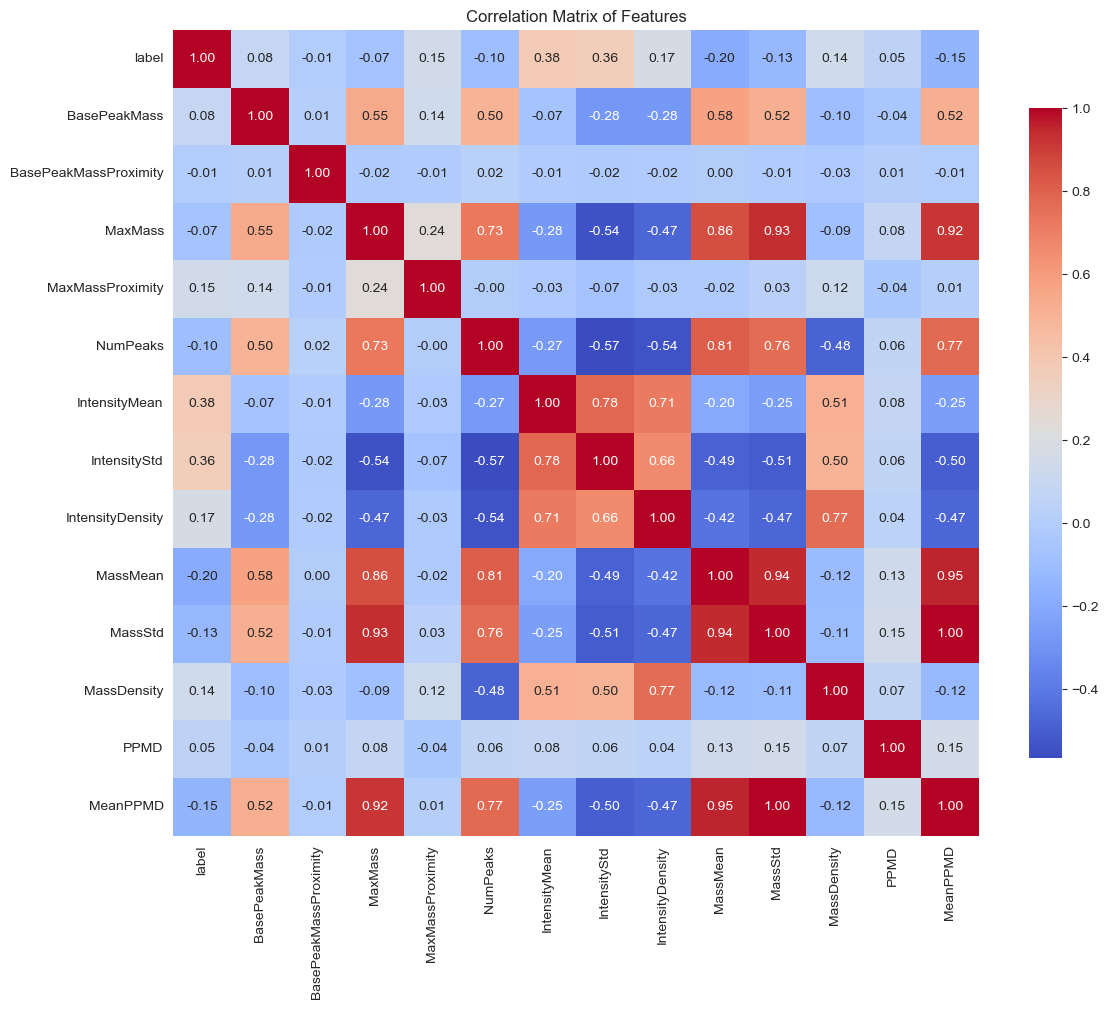

In [10]:
import seaborn as sns
full_df.drop(columns=['Name'], inplace=True)
plt.figure(figsize=(12, 10))
sns.heatmap(full_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Features')
plt.tight_layout()
plt.show()


In [11]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

X = full_df.drop(columns=['label'])
y = full_df['label']

rf = RandomForestClassifier(random_state=42)
rf.fit(X, y)
importances = pd.Series(rf.feature_importances_, index=X.columns)

corr_matrix = X.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

threshold = 0.80
to_drop = set()

for col in upper.columns:
    correlated_features = upper.index[upper[col] > threshold].tolist()
    for corr_feat in correlated_features:
        if importances[col] < importances[corr_feat]:
            to_drop.add(col)
        else:
            to_drop.add(corr_feat)

print(f"Variabili rimosse tenendo conto di importanza e correlazione (> {threshold}):", to_drop)

full_df= full_df.drop(columns=list(to_drop))

feature_columns= full_df.drop(columns=['label']).columns.tolist()
full_df.head()

Variabili rimosse tenendo conto di importanza e correlazione (> 0.8): {'MassStd', 'NumPeaks', 'MeanPPMD', 'MaxMass'}


,label,BasePeakMass,BasePeakMassProximity,MaxMassProximity,IntensityMean,IntensityStd,IntensityDensity,MassMean,MassDensity,PPMD
0,0,126.0,1.0,1.0,4.029333,14.658635,2.222000,100.711111,5.133333,2.0
1,0,72.0,1.0,2.0,2.470000,11.462612,1.315658,109.434211,2.671053,1.0
2,0,72.0,1.0,11.0,2.632703,11.673796,1.351216,103.824324,2.716216,1.0
3,0,72.0,1.0,21.0,2.506709,11.389502,1.265696,101.379747,2.481013,1.0
4,0,72.0,1.0,2.0,2.801846,12.453542,1.538308,96.184615,2.676923,1.0


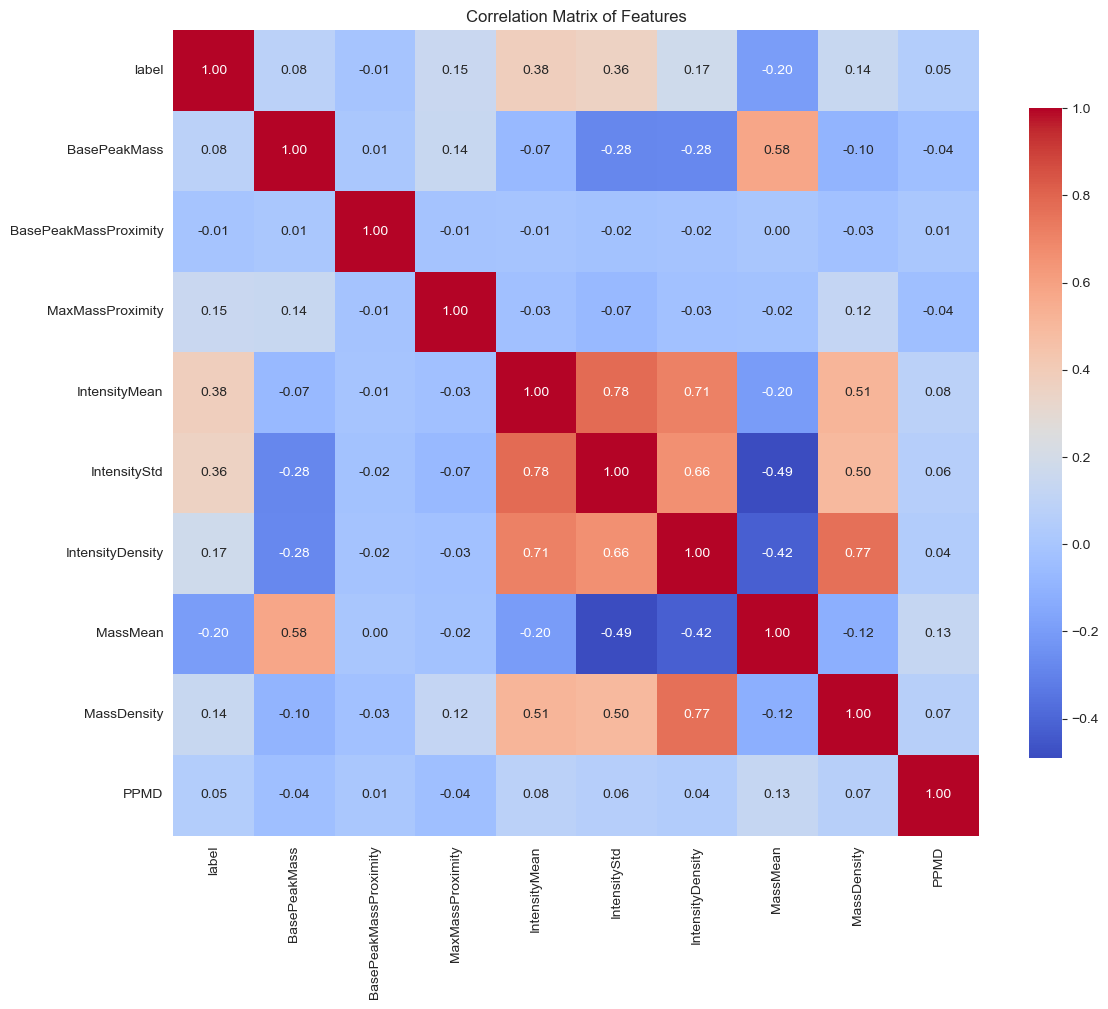

In [12]:
plt.figure(figsize=(12, 10))
sns.heatmap(full_df.corr(), annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix of Features')
plt.tight_layout()
plt.show()


Si preservano le feature più rilevanti per il modello evitando di rimuovere variabili a caso che possono essere importanti

# MODELLING


In [13]:
import pandas as pd
import numpy as np
from imblearn.ensemble import BalancedRandomForestClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

# Caricamento e preparazione dei dati 
df = full_df.copy()  

Y = df['label']
X = df.drop(['label'], axis=1)

X = np.array(X)
Y = np.array(Y)
print(X.shape, Y.shape)
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42, stratify=Y)

print(f'The training set has {x_train.shape[0]} instances and {x_train.shape[1]} features.')
print(f'The test set has {x_test.shape[0]} instances and {x_test.shape[1]} features.')

# Oversampling
smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train, y_train)

print(pd.Series(y_train).value_counts())


(891, 9) (891,)
The training set has 712 instances and 9 features.
The test set has 179 instances and 9 features.
0    177
2    177
5    177
6    177
4    177
1    177
3    177
Name: count, dtype: int64


=== Classification Report ===
                          precision    recall  f1-score   support

     Cathinone analogues       0.63      0.67      0.65        18
   Cannabinoid analogues       0.90      0.87      0.88        30
Phenethylamine analogues       0.48      0.45      0.47        22
    Piperazine analogues       0.56      0.90      0.69        10
    Tryptamine analogues       0.54      0.54      0.54        13
      Fentanyl analogues       0.85      0.89      0.87        45
         Other compounds       0.85      0.71      0.77        41

                accuracy                           0.74       179
               macro avg       0.69      0.72      0.70       179
            weighted avg       0.75      0.74      0.74       179


=== Confusion Matrix ===


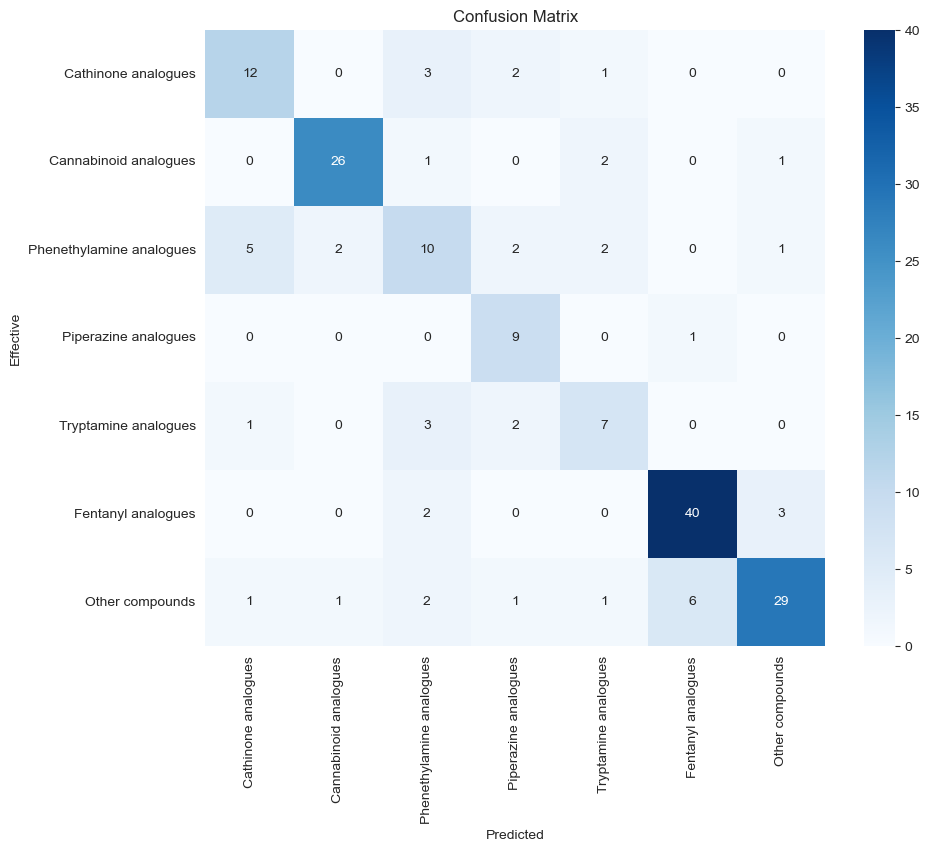


Cross-validation accuracy (4-fold): 0.87 ± 0.05


In [14]:
import seaborn as sns

# Classificatore Balanced Random Forest 
clf = BalancedRandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(x_train, y_train)

# Valutazione
y_pred = clf.predict(x_test)
print("=== Classification Report ===")
class_labels = [legends[i] for i in clf.classes_]
print(classification_report(y_test, y_pred, target_names=class_labels))
print("\n=== Confusion Matrix ===")
confusion_matrix_result = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix_result, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Effective')
plt.grid(False)
plt.show()    

# Cross-validation 
scores = cross_val_score(clf, x_train, y_train, cv=4)
print(f"\nCross-validation accuracy (4-fold): {scores.mean():.2f} ± {scores.std():.2f}")

In [15]:
import joblib

In [16]:
joblib.dump(clf, 'model/balanced_random_forest_brf.pkl')

['model/balanced_random_forest_brf.pkl']

C:\Users\simon\AppData\Local\Temp\ipykernel_23284\3379792084.py:20: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


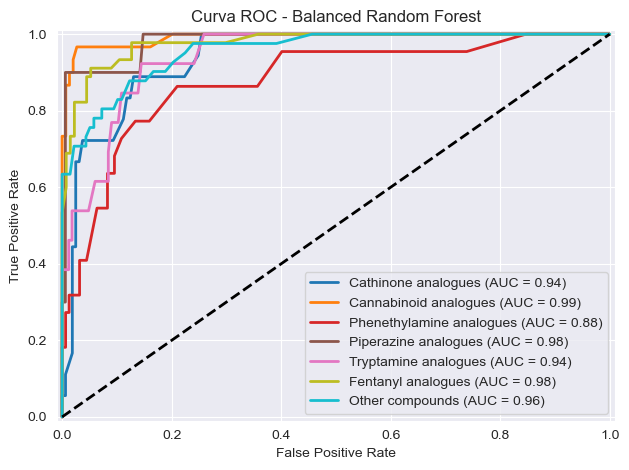

In [17]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np

classes = np.unique(y_test)
n_classes = len(classes)
y_test_bin = label_binarize(y_test, classes=classes)
y_score = clf.predict_proba(x_test)

# Curva ROC (multi-classe One-vs-Rest)
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

colors = plt.cm.get_cmap('tab10', n_classes)

for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors(i), lw=2,
             label=f"{class_labels[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Balanced Random Forest')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


Fitting estimator with 9 features.
Fitting estimator with 8 features.
Fitting estimator with 7 features.
Fitting estimator with 6 features.


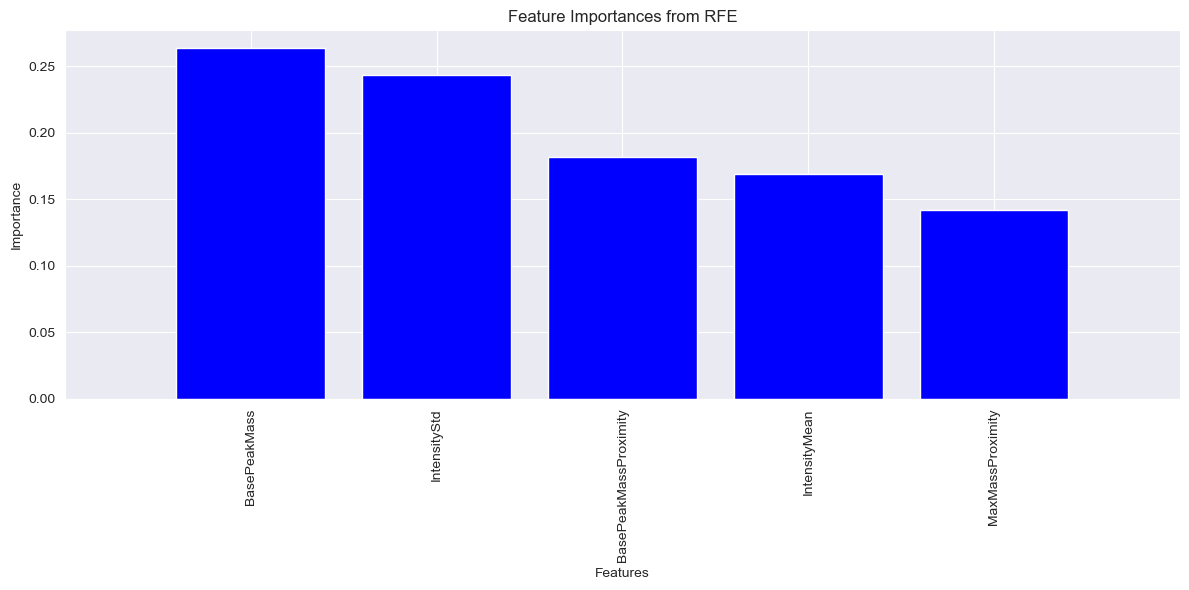

In [18]:
#feature importance
from sklearn.feature_selection import RFE
rfe_base_clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf_rfe = RFE(rfe_base_clf, n_features_to_select=5, verbose=1)
clf_rfe.fit(x_train, y_train)

importances = clf_rfe.estimator_.feature_importances_
indices = np.argsort(importances)[::-1]

# Plot delle feature importances
plt.figure(figsize=(12, 6))
plt.title("Feature Importances from RFE")
plt.bar(range(len(importances)), importances[indices], color='b', align='center')
plt.xticks(range(len(importances)), [feature_columns[i] for i in indices], rotation=90)
plt.xlim([-1, len(importances)])
plt.xlabel("Features")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()

Feature selezionate: ['BasePeakMass' 'IntensityMean' 'IntensityStd' 'IntensityDensity'
 'MassMean']
=== Classification Report after RFE ===
                          precision    recall  f1-score   support

     Cathinone analogues       0.52      0.67      0.59        18
   Cannabinoid analogues       0.90      0.93      0.92        30
Phenethylamine analogues       0.53      0.36      0.43        22
    Piperazine analogues       0.57      0.80      0.67        10
    Tryptamine analogues       0.47      0.54      0.50        13
      Fentanyl analogues       0.81      0.87      0.84        45
         Other compounds       0.88      0.71      0.78        41

                accuracy                           0.73       179
               macro avg       0.67      0.70      0.67       179
            weighted avg       0.74      0.73      0.73       179



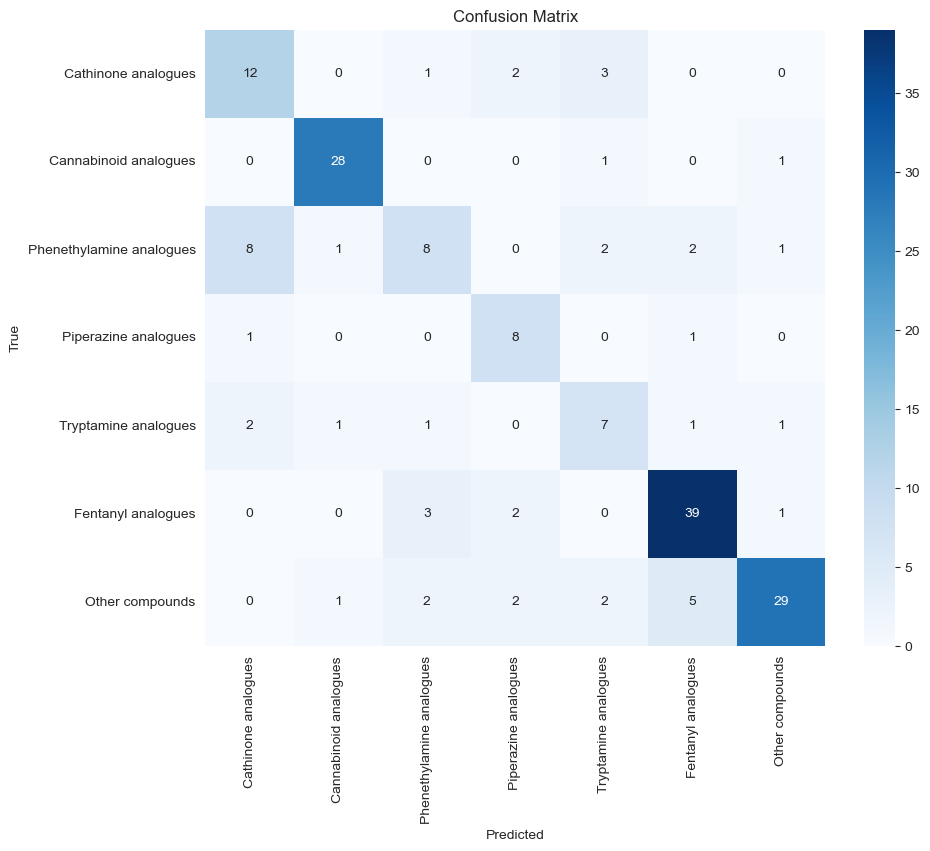


Cross-validation accuracy (4-fold) after RFE: 0.84 ± 0.02


In [19]:
# Selezione boolean array delle feature scelte da RFE
selected_indices = clf_rfe.support_

selected_features = np.array(feature_columns)[selected_indices]
print("Feature selezionate:", selected_features)

if isinstance(x_train, pd.DataFrame):
    X_train_selected = x_train.loc[:, selected_features].values
    X_test_selected = x_test.loc[:, selected_features].values
else:
    X_train_selected = x_train[:, selected_indices]
    X_test_selected = x_test[:, selected_indices]

bdt_clf_rfe = BalancedRandomForestClassifier(n_estimators=100, random_state=42)
bdt_clf_rfe.fit(X_train_selected, y_train)

y_pred_rfe = bdt_clf_rfe.predict(X_test_selected)

print("=== Classification Report after RFE ===")
print(classification_report(y_test, y_pred_rfe, target_names=class_labels))

confusion_matrix_result = confusion_matrix(y_test, y_pred_rfe)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix_result, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.grid(False)
plt.show()

from sklearn.model_selection import StratifiedKFold, cross_val_score

cv = StratifiedKFold(n_splits=4, shuffle=True, random_state=42)
scores = cross_val_score(bdt_clf_rfe, X_train_selected, y_train, cv=cv)

print(f"\nCross-validation accuracy (4-fold) after RFE: {scores.mean():.2f} ± {scores.std():.2f}")


In [20]:
joblib.dump(bdt_clf_rfe, 'model/balanced_random_forest_rfe.pkl')

['model/balanced_random_forest_rfe.pkl']

C:\Users\simon\AppData\Local\Temp\ipykernel_23284\3736490985.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


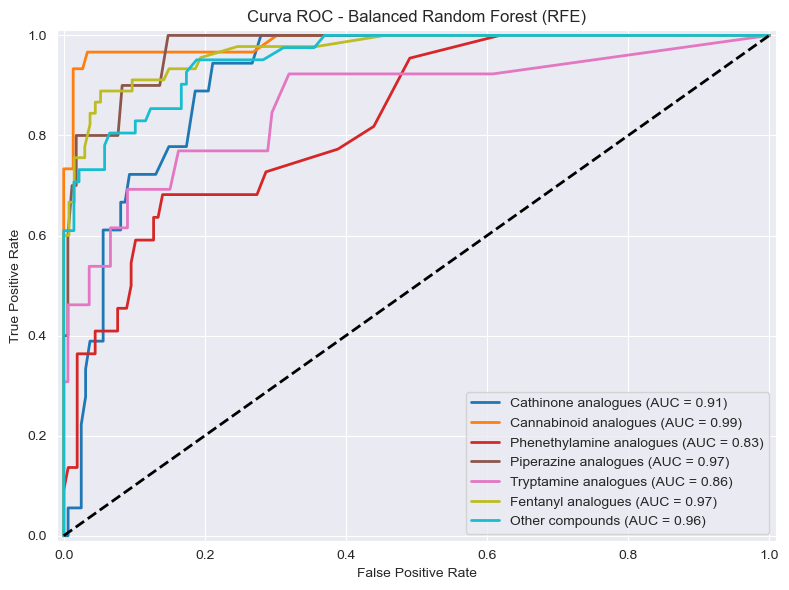

In [21]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

classes = np.unique(y_test)
n_classes = len(classes)
y_test_bin = label_binarize(y_test, classes=classes)
y_score_rfe = bdt_clf_rfe.predict_proba(X_test_selected)

# Calcola fpr, tpr, auc per ogni classe
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score_rfe[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

plt.figure(figsize=(8, 6))
colors = plt.cm.get_cmap('tab10', n_classes)
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors(i), lw=2,
             label=f"{class_labels[i]} (AUC = {roc_auc[i]:.2f})")
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Balanced Random Forest (RFE)')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

Best parameters found:  {'n_estimators': 150, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 50, 'criterion': 'entropy'}
Best cross-validation score:  0.8587570621468927

=== Classification Report (Best Model) ===
                          precision    recall  f1-score   support

     Cathinone analogues       0.72      0.72      0.72        18
   Cannabinoid analogues       0.90      0.87      0.88        30
Phenethylamine analogues       0.59      0.45      0.51        22
    Piperazine analogues       0.56      0.90      0.69        10
    Tryptamine analogues       0.50      0.54      0.52        13
      Fentanyl analogues       0.82      0.89      0.85        45
         Other compounds       0.86      0.76      0.81        41

                accuracy                           0.76       179
               macro avg       0.71      0.73      0.71       179
            weighted avg       0.77      0.76      0.76       179


=== Confusion Matrix (Best Model) ===


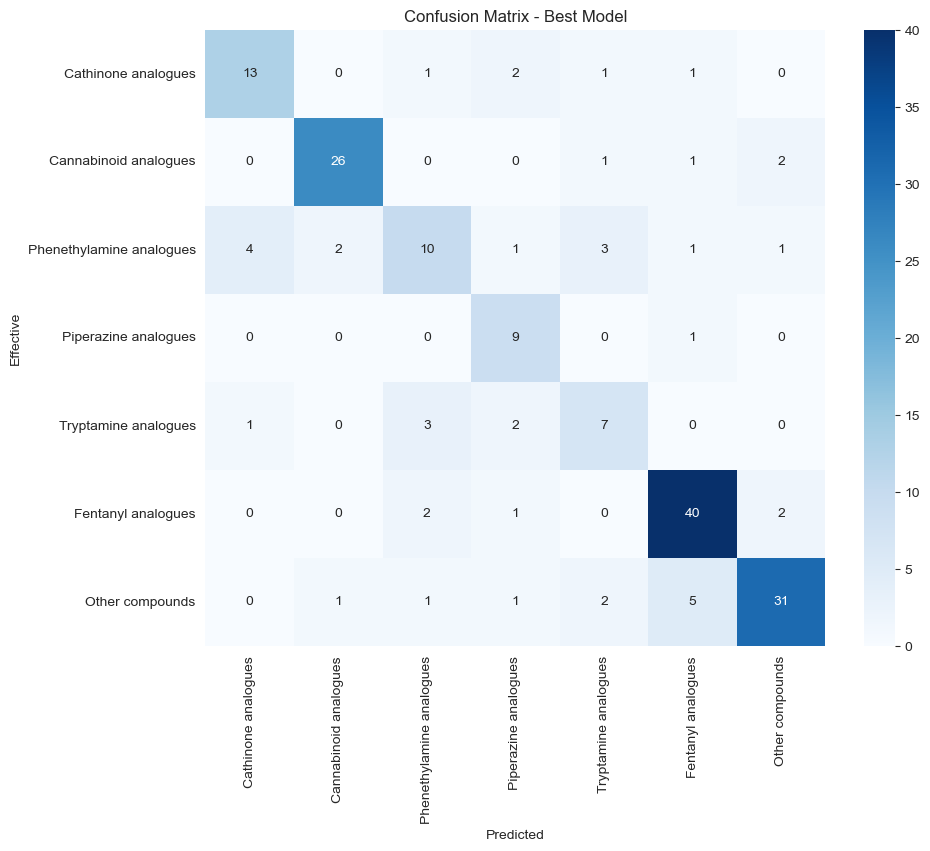


=== Cross-validation score (Best Model) ===
Cross-validation accuracy (4-fold): 0.67 ± 0.06


In [22]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix

# Hyperparameters Tuning
param_distributions = {
    'n_estimators': [10, 50, 100, 150],
    'max_depth': [None, 5, 10, 20, 50],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

random_search = RandomizedSearchCV(
    estimator=bdt_clf_rfe,
    param_distributions=param_distributions,
    n_iter=20, 
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42
)

random_search.fit(x_train, y_train)

# Risultati
print("Best parameters found: ", random_search.best_params_)
print("Best cross-validation score: ", random_search.best_score_)

# Valutazione del modello ottimizzato
best_clf = random_search.best_estimator_
y_pred_best = best_clf.predict(x_test)

print("\n=== Classification Report (Best Model) ===")
print(classification_report(y_test, y_pred_best, target_names=class_labels))

print("\n=== Confusion Matrix (Best Model) ===")

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - Best Model')
plt.xlabel('Predicted')
plt.ylabel('Effective')
plt.grid(False)
plt.show()

print("\n=== Cross-validation score (Best Model) ===")
scores_best = cross_val_score(best_clf, x_test, y_test, cv=4)
print(f"Cross-validation accuracy (4-fold): {scores_best.mean():.2f} ± {scores_best.std():.2f}")



=== Albero di decisione ===


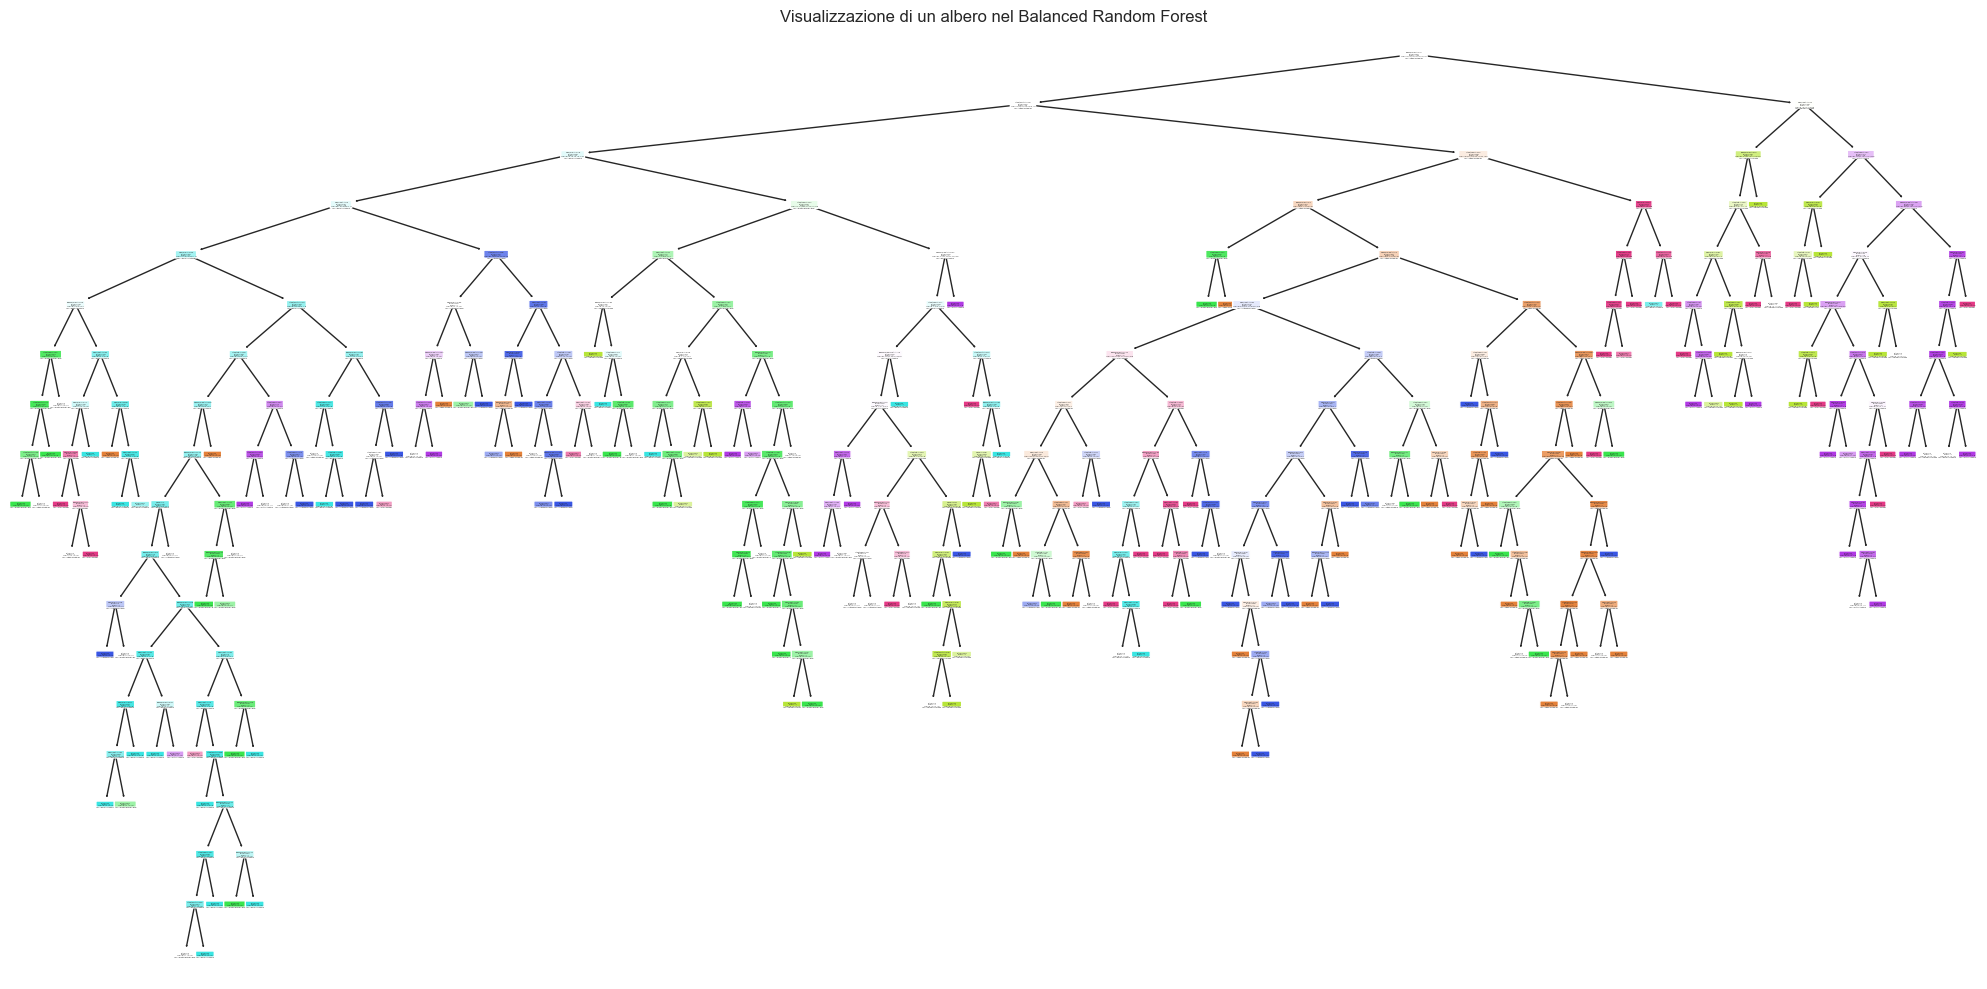


=== Metriche medie degli alberi ===
n_nodes      361.333333
max_depth     14.386667
dtype: float64


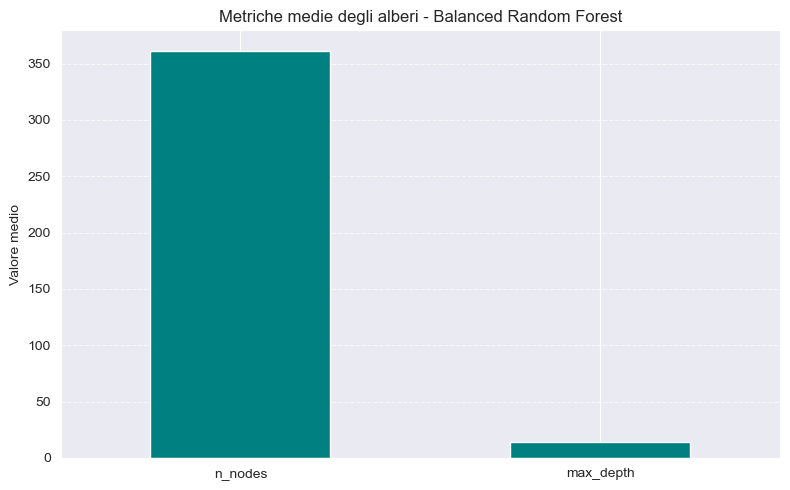

In [23]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import pandas as pd

print("\n=== Albero di decisione ===")

plt.figure(figsize=(20, 10))
plot_tree(
    best_clf.estimators_[0],
    feature_names=feature_columns,
    class_names=[legends[i] for i in best_clf.classes_],
    filled=True,
    rounded=True,
)
plt.title("Visualizzazione di un albero nel Balanced Random Forest")
plt.tight_layout()
plt.show()

print("\n=== Metriche medie degli alberi ===")
metrics = {
    'n_nodes': [est.tree_.node_count for est in best_clf.estimators_],
    'max_depth': [est.tree_.max_depth for est in best_clf.estimators_]
}
metrics_df = pd.DataFrame(metrics)
print(metrics_df.mean())

# === 3. Visualizzazione delle metriche medie ===
metrics_df.mean().plot(kind='bar', figsize=(8, 5), color='teal')
plt.title('Metriche medie degli alberi - Balanced Random Forest')
plt.ylabel('Valore medio')
plt.xticks(rotation=0)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


C:\Users\simon\AppData\Local\Temp\ipykernel_23284\948636324.py:22: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


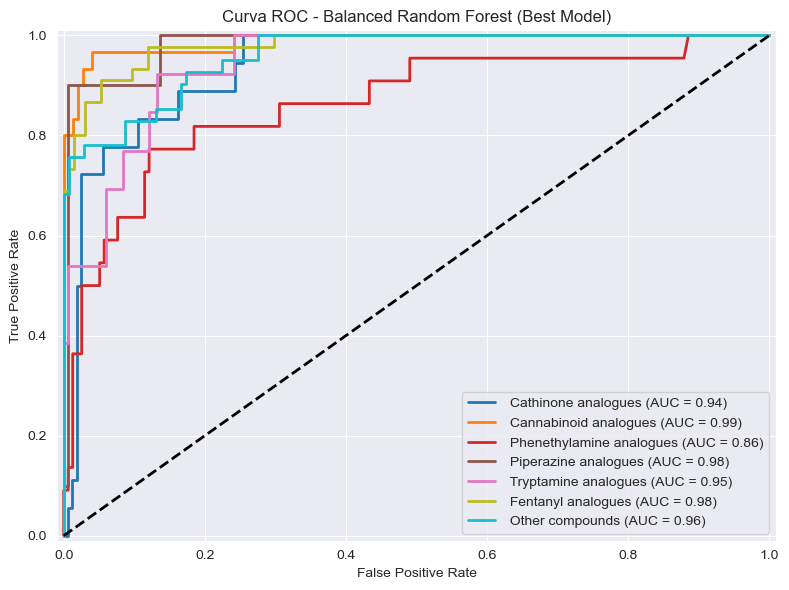

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

classes = np.unique(y_test)
n_classes = len(classes)

y_test_bin = label_binarize(y_test, classes=classes)
y_score = best_clf.predict_proba(x_test)

# Calcolo della curva ROC per ogni classe
fpr = dict()
tpr = dict()
roc_auc = dict()

for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
    
plt.figure(figsize=(8, 6))
colors = plt.cm.get_cmap('tab10', n_classes)
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors(i), lw=2,
             label=f" {class_labels[i]} (AUC = {roc_auc[i]:.2f})")

plt.plot([0, 1], [0, 1], 'k--', lw=2)

plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - Balanced Random Forest (Best Model)')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [25]:
joblib.dump(best_clf, 'model/balanced_random_forest_brf_hmp.pkl')

['model/balanced_random_forest_brf_hmp.pkl']

In [26]:
spectrum_dataset= nps_dataset.copy().drop(columns=['Name'])
print(f'The spectrum dataset has {spectrum_dataset.shape[0]} instances and {spectrum_dataset.shape[1]} features.')
spectrum_dataset.head()

The spectrum dataset has 891 instances and 601 features.


,1,2,3,4,5,6,7,8,9,10,...,592,593,594,595,596,597,598,599,600,label
0,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0


In [27]:
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping
#import graphviz

model = keras.Sequential(name = 'dnn')
model.add(keras.Input(shape=(600,)))
model.add(layers.Dense(300, activation = 'relu'))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(30, activation = 'relu'))
model.add(layers.Dropout(0.2))
model.add(layers.Dense(7, activation = 'softmax'))

from tensorflow.keras.utils import plot_model
print(model.summary())

plot_model(model, to_file="dnn_model_structure.png", show_shapes=True, show_layer_names=True, dpi=96,)

Model: "dnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 300)            │       180,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 300)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 30)             │         9,030 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 7)              │           217 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 189,547 (740.42 KB)

 Trainable params: 189,547 (740.42 KB)

 Non-trainable params: 0 (0.00 B)

None
You must install pydot (`pip install pydot`) for `plot_model` to work.


In [28]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy', 
    metrics=['accuracy'],
)

Y = spectrum_dataset['label']
X = spectrum_dataset.drop(['label'], axis=1)

X = np.array(X)
Y = np.array(Y)
print(X.shape, Y.shape)
x_train, x_test, y_train, y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

print(f'The training set has {x_train.shape[0]} instances and {x_train.shape[1]} features.')
print(f'The test set has {x_test.shape[0]} instances and {x_test.shape[1]} features.')

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
print(pd.Series(y_train).value_counts())

# oversampling
smote = SMOTE(random_state=42)
x_train, y_train = smote.fit_resample(x_train, y_train)

print(pd.Series(y_train).value_counts())

early_stop = EarlyStopping(
    monitor='val_loss',    
    patience=5,            
    restore_best_weights=True 
)

history= model.fit(
    x_train, y_train,  
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop] 
)

(891, 600) (891,)
The training set has 712 instances and 600 features.
The test set has 179 instances and 600 features.
5    179
6    165
1    122
2     83
0     70
4     58
3     35
Name: count, dtype: int64
3    179
6    179
4    179
1    179
5    179
0    179
2    179
Name: count, dtype: int64
Epoch 1/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - accuracy: 0.4611 - loss: 1.5487 - val_accuracy: 0.1514 - val_loss: 1.8810
Epoch 2/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7405 - loss: 0.8450 - val_accuracy: 0.5299 - val_loss: 1.2986
Epoch 3/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.8443 - loss: 0.5359 - val_accuracy: 0.6813 - val_loss: 0.8190
Epoch 4/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.8882 - loss: 0.3850 - val_accuracy: 0.8247 - val_loss: 0.5299
Epoch 5/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9242 - loss: 0.2918 - val_accuracy: 0.8685 - val_loss: 0.3448
Epoch 6/50
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9431 - 

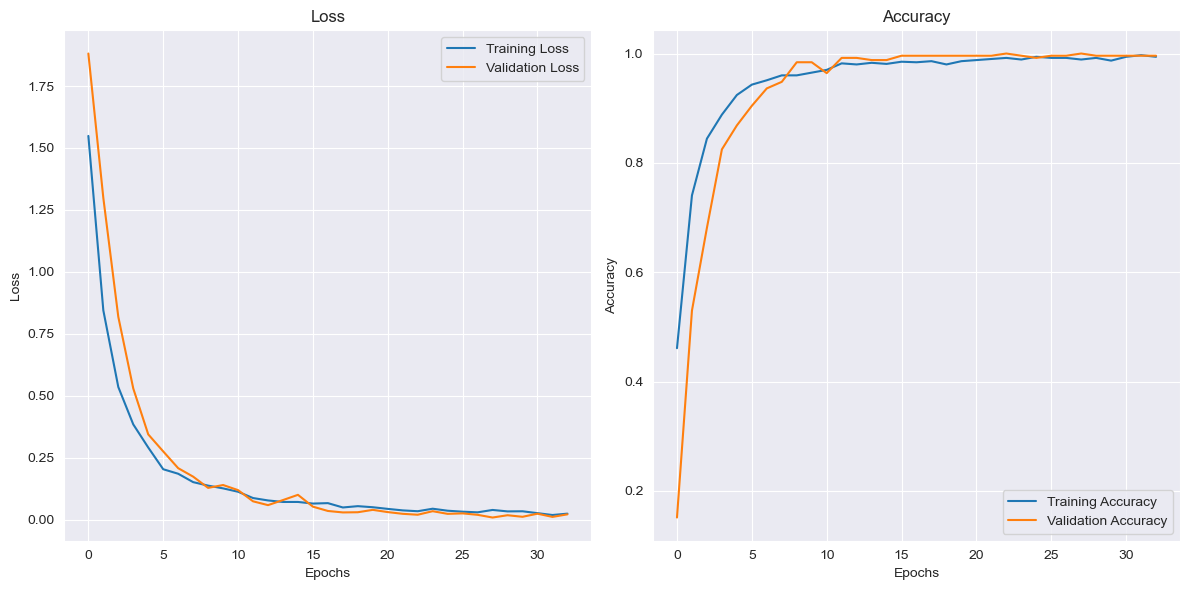

In [29]:
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
=== Classification Report ===
                          precision    recall  f1-score   support

     Cathinone analogues       0.74      0.74      0.74        19
   Cannabinoid analogues       0.87      0.74      0.80        27
Phenethylamine analogues       0.77      0.83      0.80        29
    Piperazine analogues       0.80      0.80      0.80        15
    Tryptamine analogues       0.57      0.89      0.70         9
      Fentanyl analogues       0.89      0.91      0.90        43
         Other compounds       0.79      0.70      0.74        37

                accuracy                           0.80       179
               macro avg       0.78      0.80      0.78       179
            weighted avg       0.81      0.80      0.80       179


=== Confusion Matrix ===


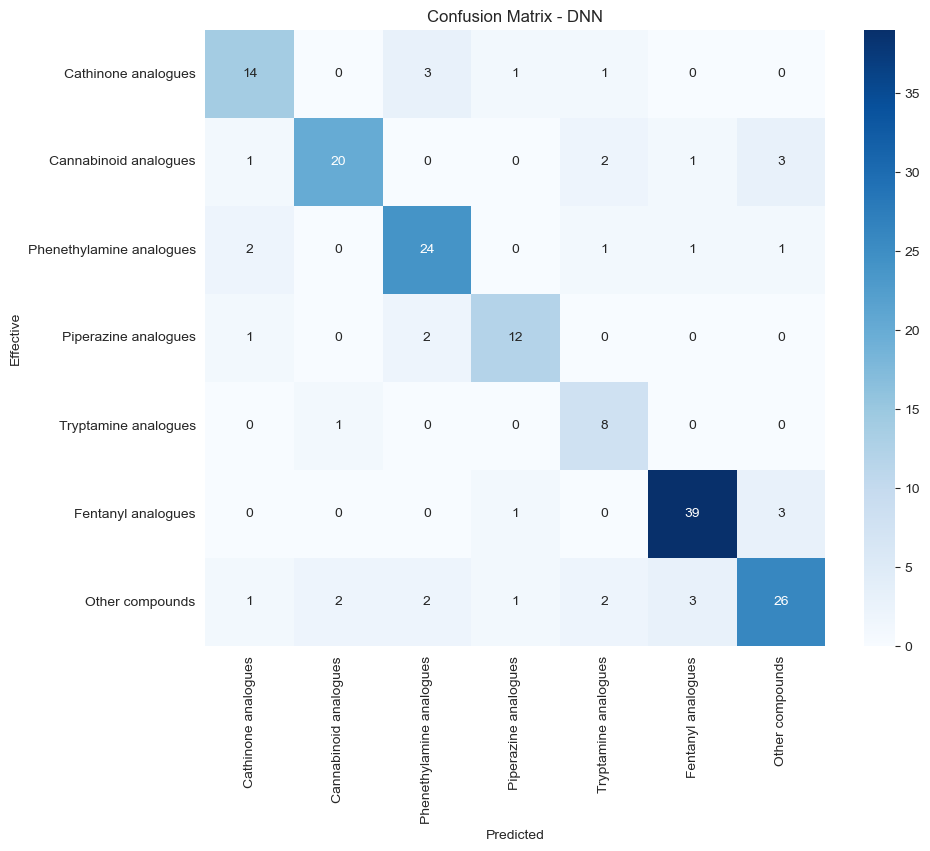

In [30]:
y_pred = model.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)

print("=== Classification Report ===")
print(classification_report(y_test, y_pred_classes, target_names=class_labels))
print("\n=== Confusion Matrix ===")
confusion_matrix_result = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix_result, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels, yticklabels=class_labels)
plt.title('Confusion Matrix - DNN')
plt.xlabel('Predicted')
plt.ylabel('Effective')
plt.grid(False)
plt.show()


6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


C:\Users\simon\AppData\Local\Temp\ipykernel_23284\945558001.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap('tab10', n_classes)


<Figure size 800x600 with 0 Axes>

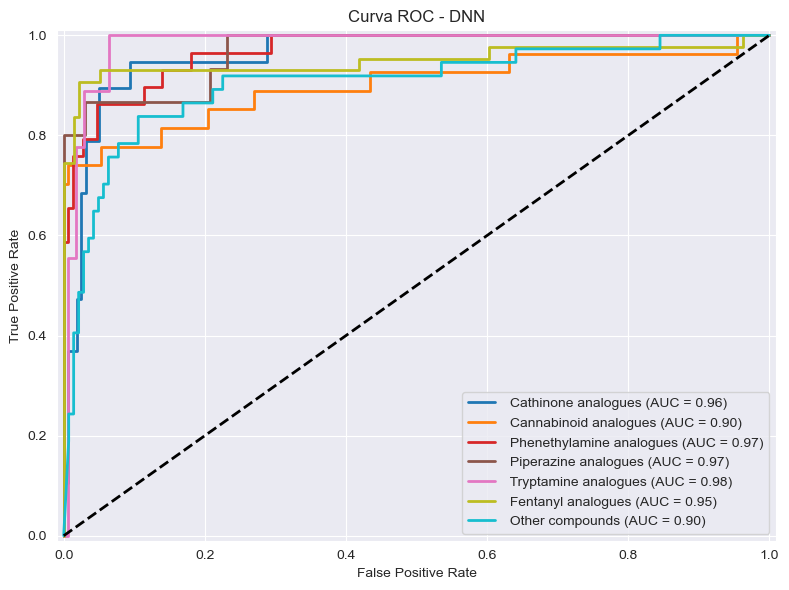

In [31]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

classes = np.unique(y_test)
n_classes = len(classes)
y_test_bin = label_binarize(y_test, classes=classes)
y_score = model.predict(x_test)
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])
plt.figure(figsize=(8, 6))
# === Plot della curva ROC ===
n_classes = len(classes)
plt.figure(figsize=(8, 6))
colors = plt.cm.get_cmap('tab10', n_classes)
for i in range(n_classes):
    plt.plot(fpr[i], tpr[i], color=colors(i), lw=2,
                label=f" {class_labels[i]} (AUC = {roc_auc[i]:.2f})")
# Linea di riferimento
plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([-0.01, 1.01])
plt.ylim([-0.01, 1.01])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC - DNN')
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

In [32]:
model.save('model/dnn_spectra_version.keras')
joblib.dump(scaler, "model/scale_dnn.pkl")

['model/scale_dnn.pkl']

 Fold   ValAcc   TrainAcc      Gap   N feat
---------------------------------------------
  Feature selezionate: 125 / 600 (stat: 100, physics-only: 25)
    1   84.92%     96.55%  +11.63%      125
  Feature selezionate: 125 / 600 (stat: 100, physics-only: 25)
    2   87.64%     96.71%   +9.07%      125
  Feature selezionate: 123 / 600 (stat: 100, physics-only: 23)
    3   85.96%     97.01%  +11.06%      123
  Feature selezionate: 122 / 600 (stat: 100, physics-only: 22)
    4   92.13%     96.85%   +4.72%      122
  Feature selezionate: 126 / 600 (stat: 100, physics-only: 26)
    5   87.64%     96.87%   +9.23%      126

Mean CV Accuracy: 87.66% ± 2.47%

=== Classification Report (aggregato 5-fold) ===
                          precision    recall  f1-score   support

     Cathinone analogues       0.79      0.82      0.81        89
   Cannabinoid analogues       0.88      0.90      0.89       149
Phenethylamine analogues       0.82      0.88      0.85       112
    Piperazine analogues  

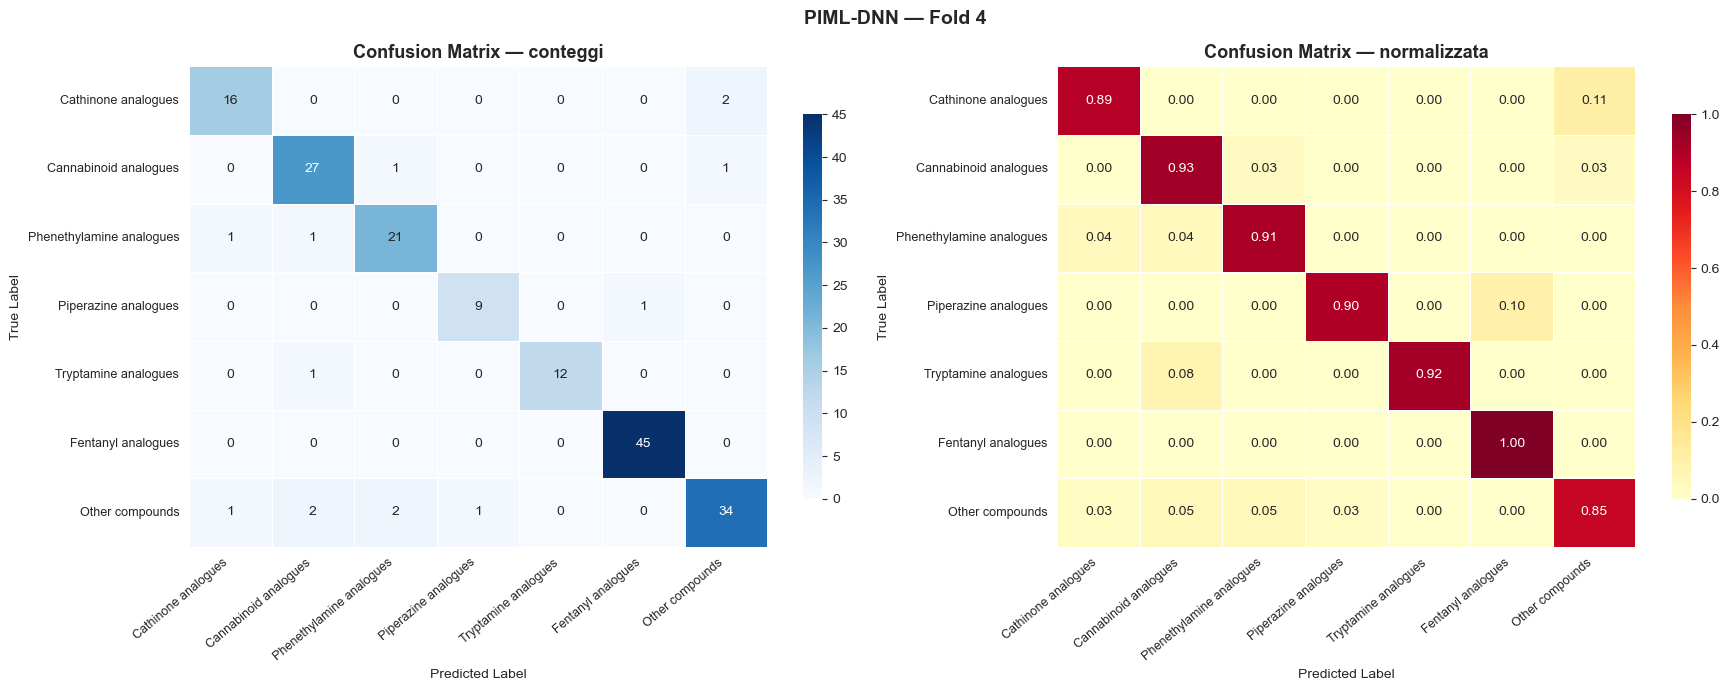

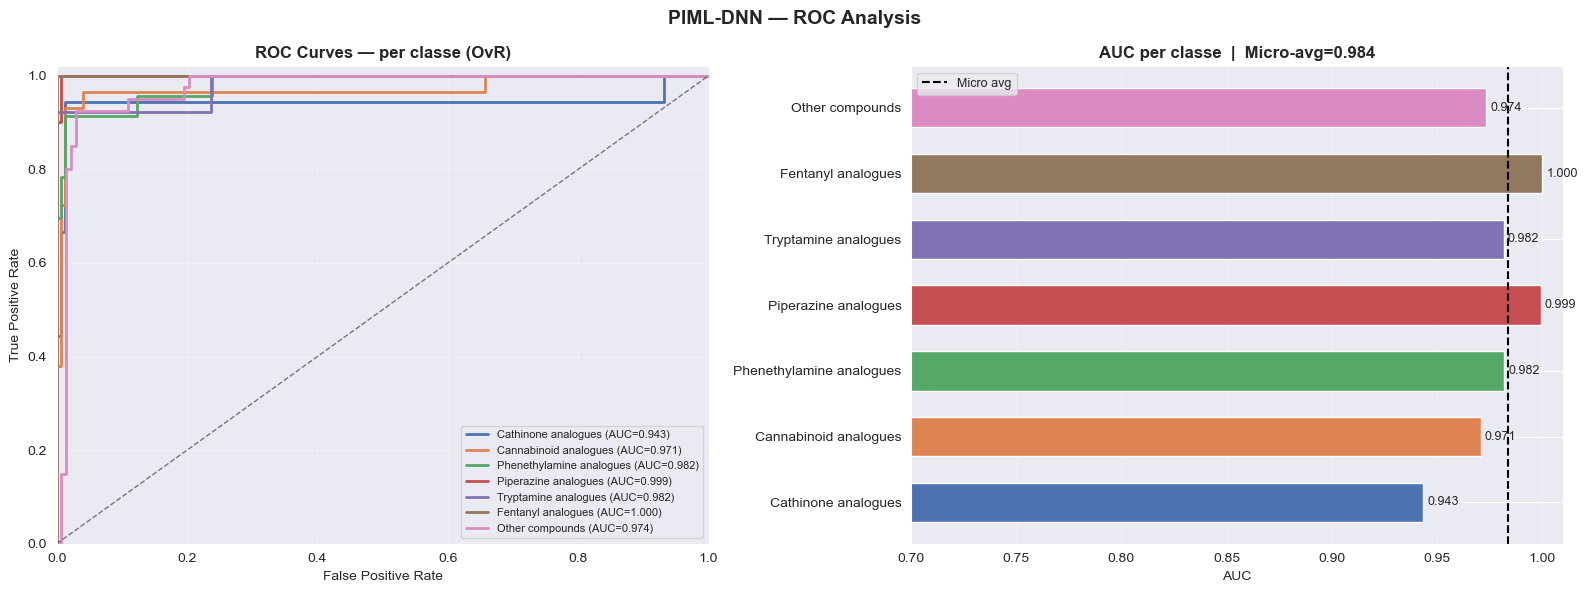

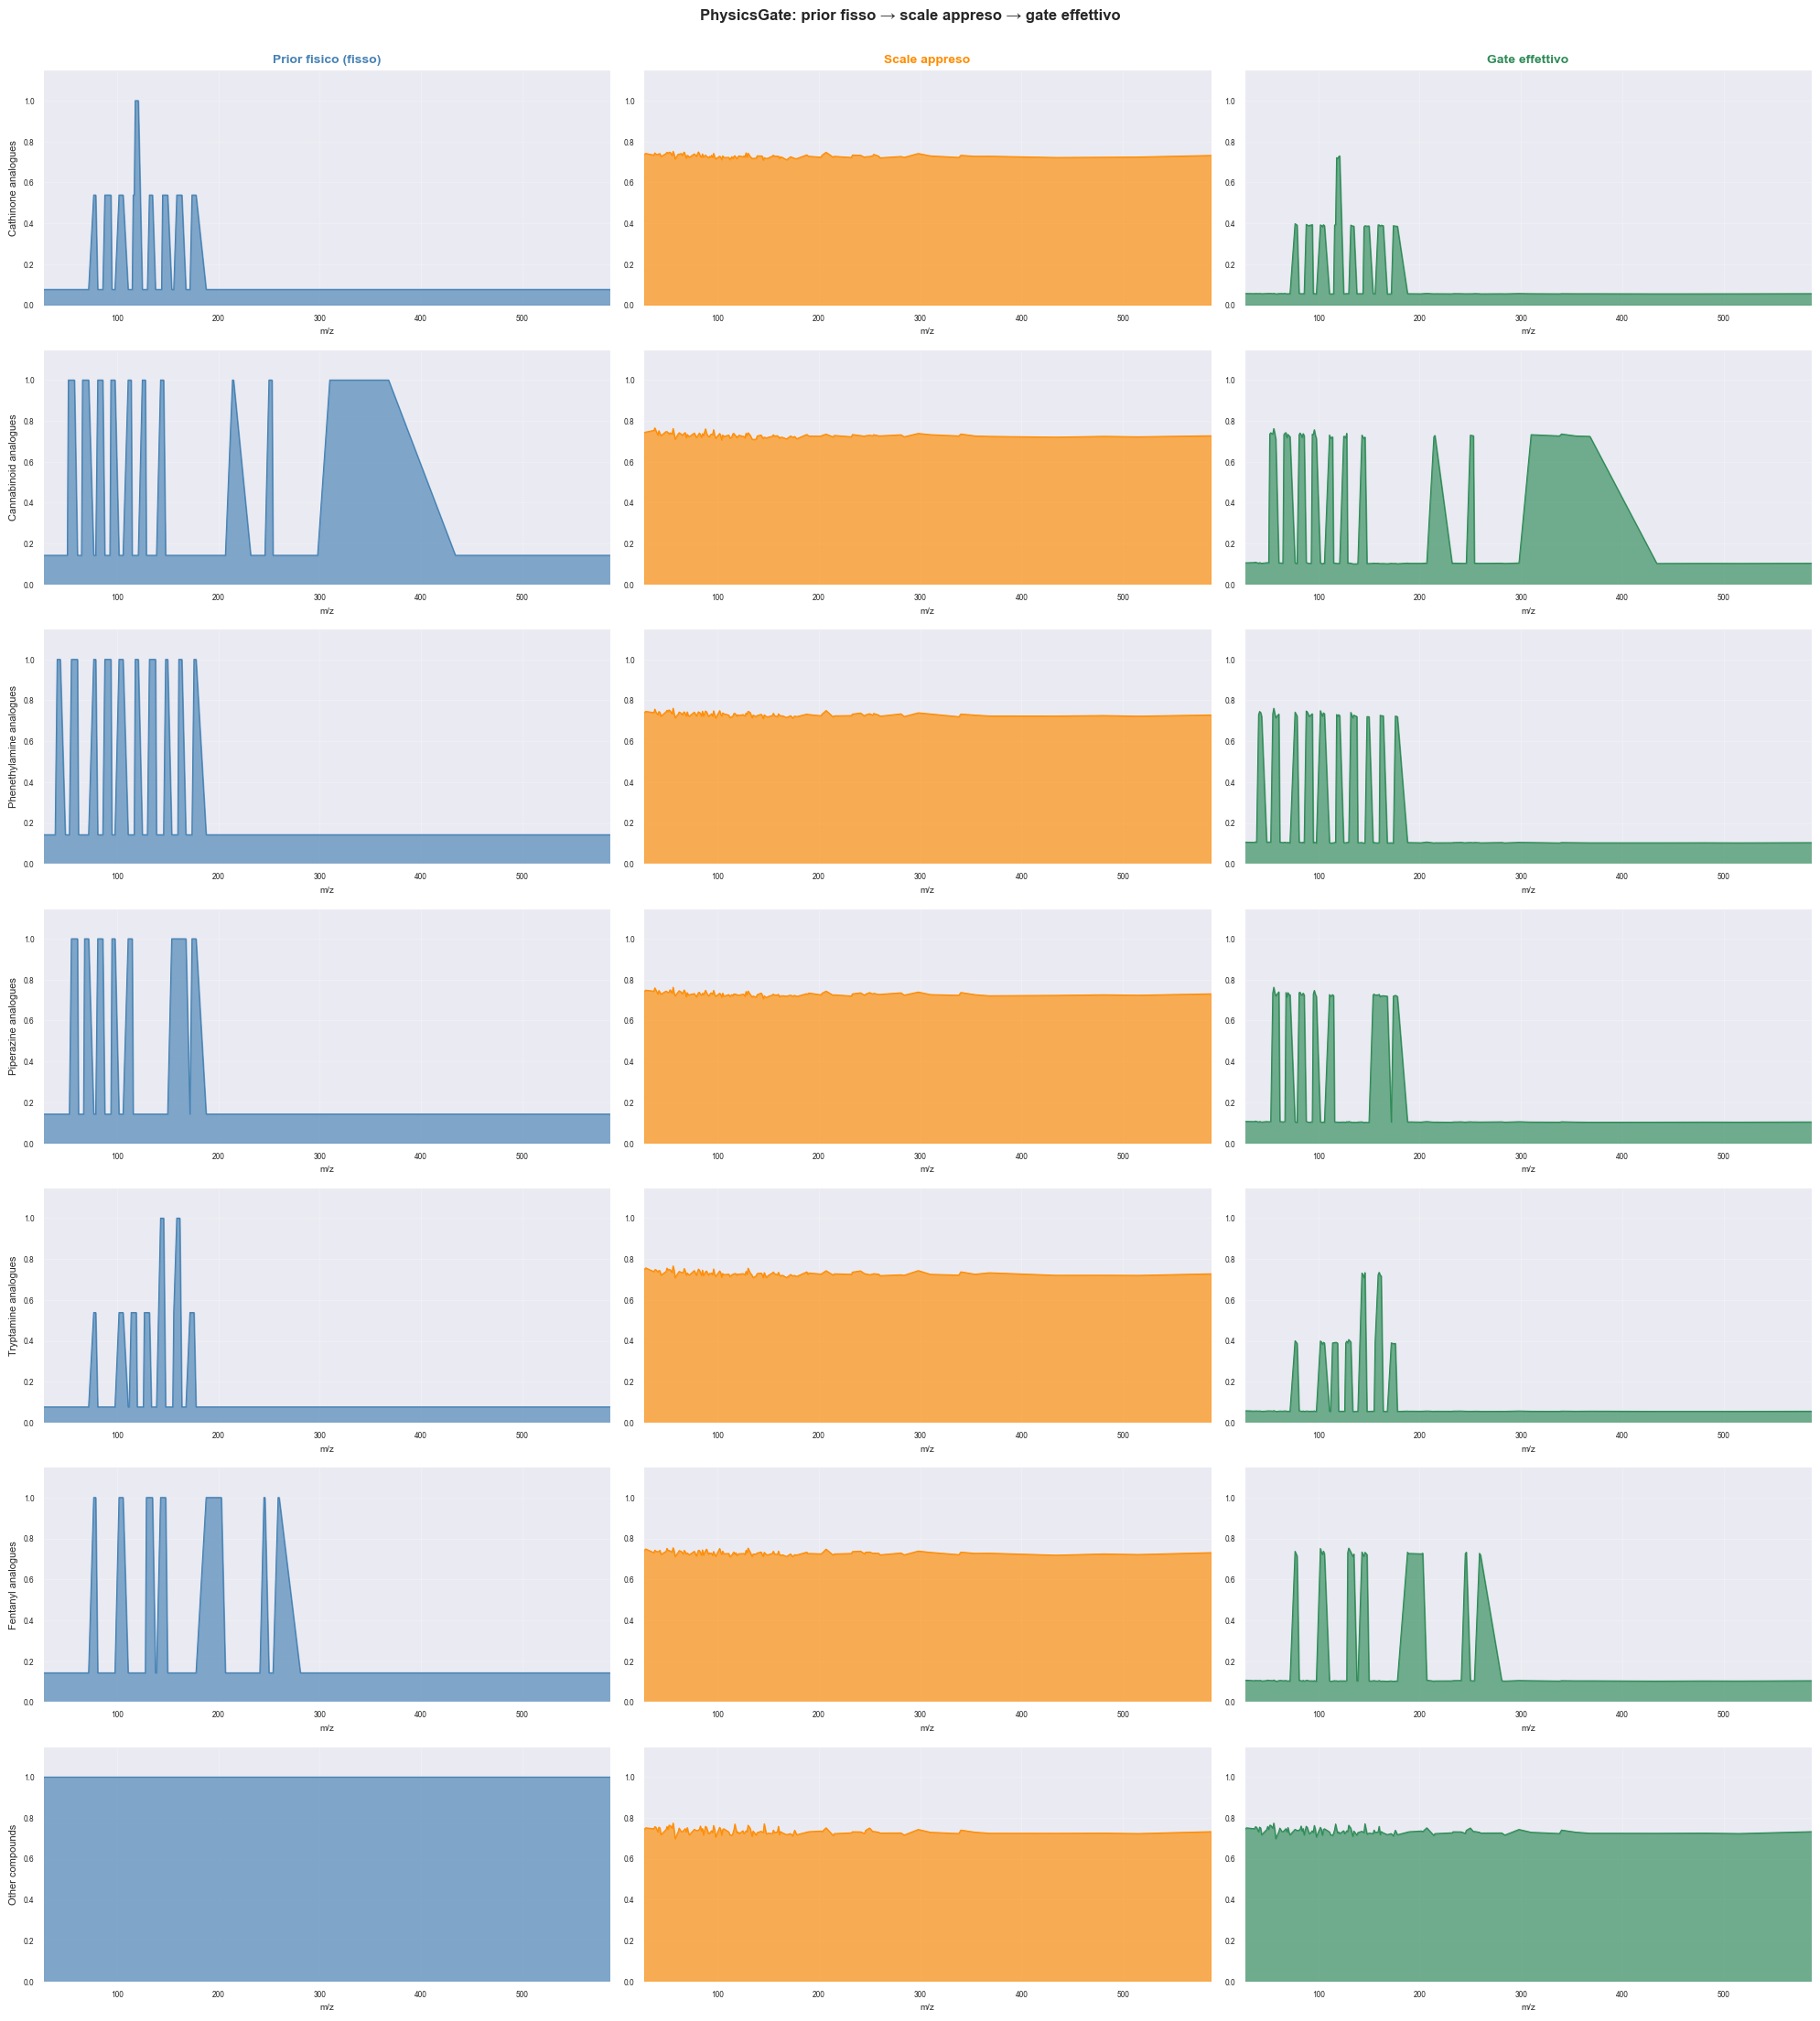

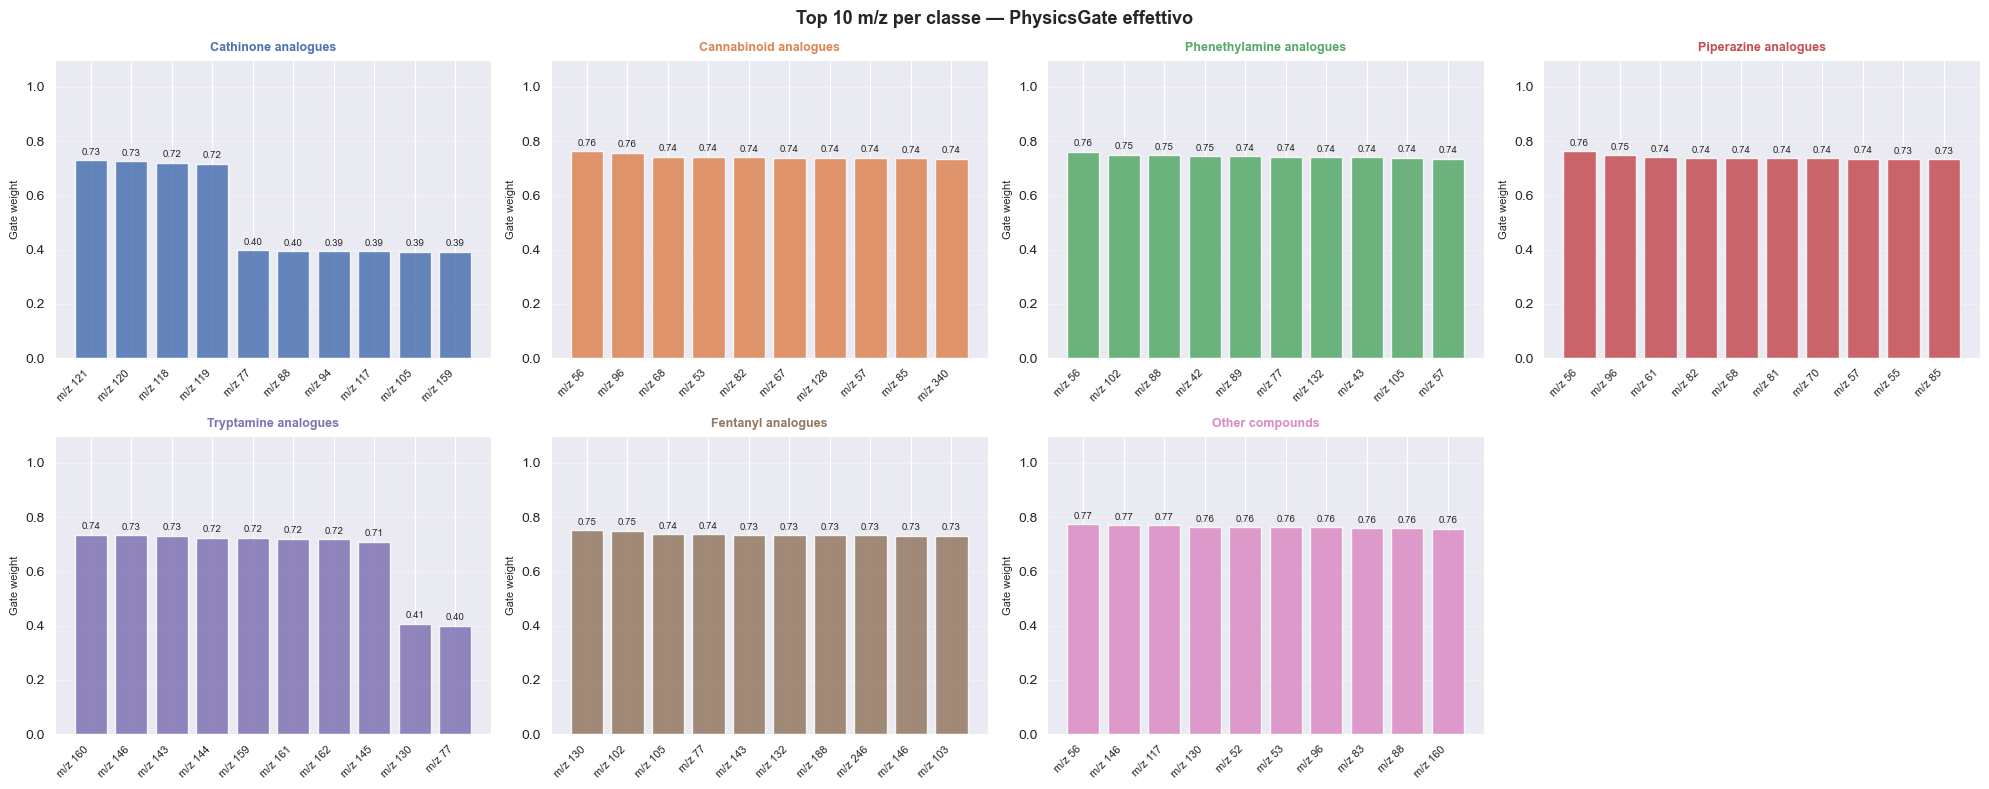

MC Dropout accuracy: 90.45%
Uncertainty corretti: 0.0765
Uncertainty errati:   0.1027


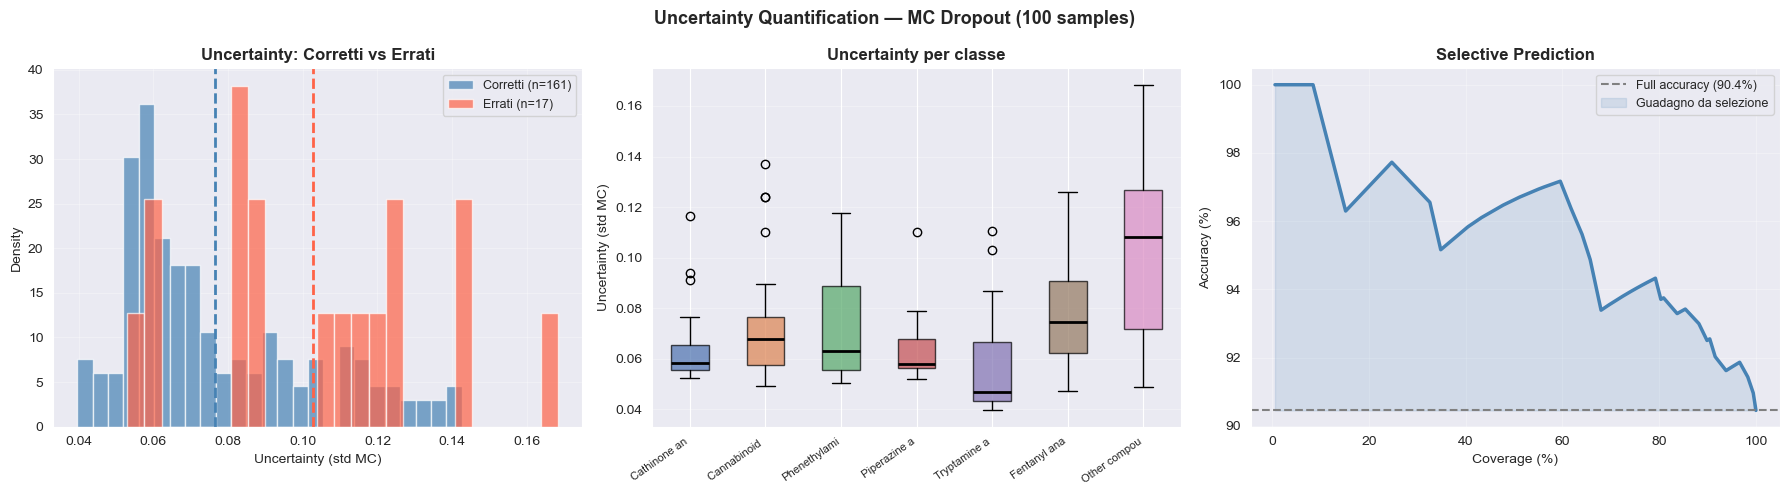

BRF accuracy: 93.82%


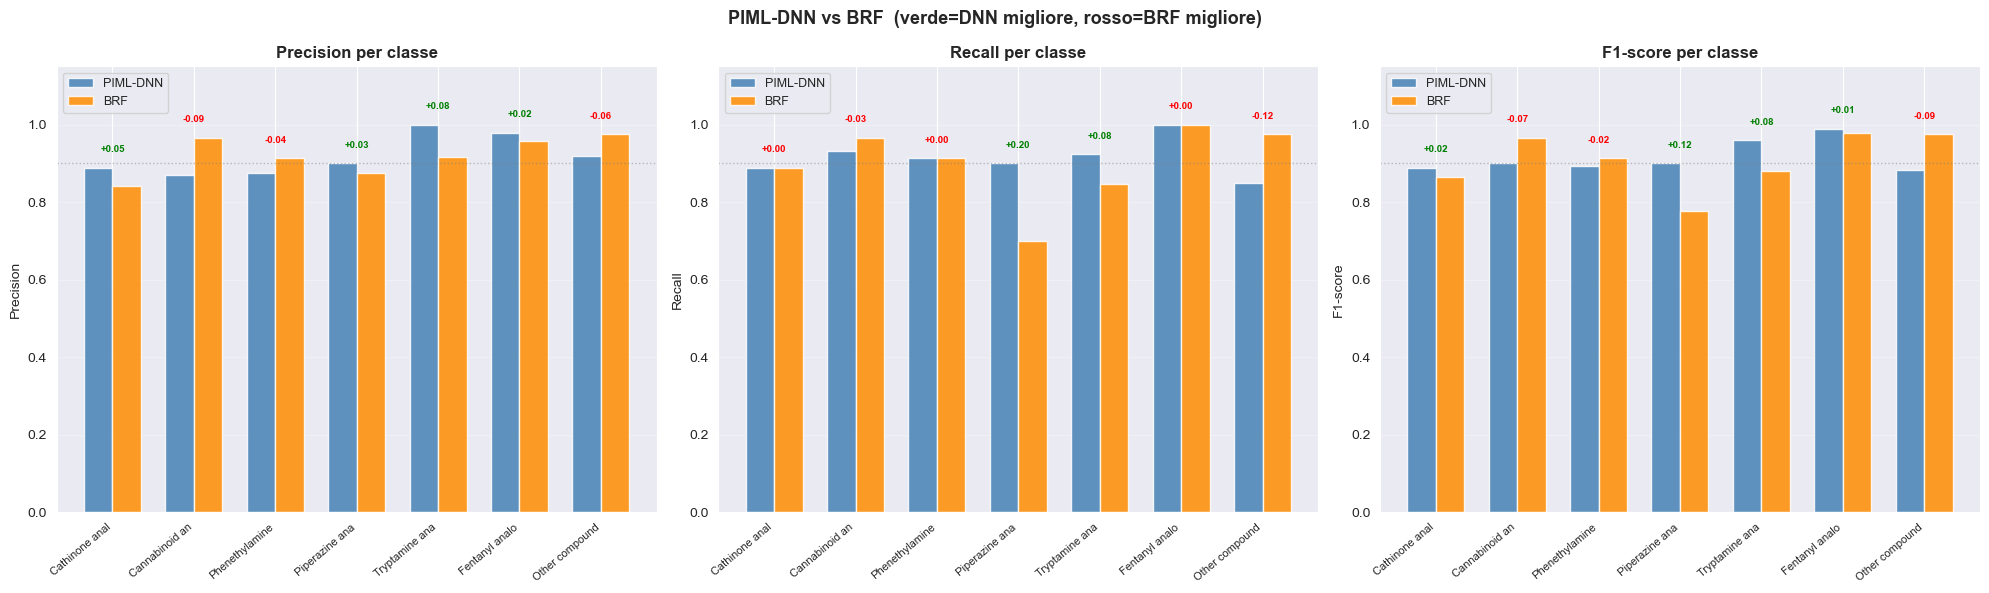

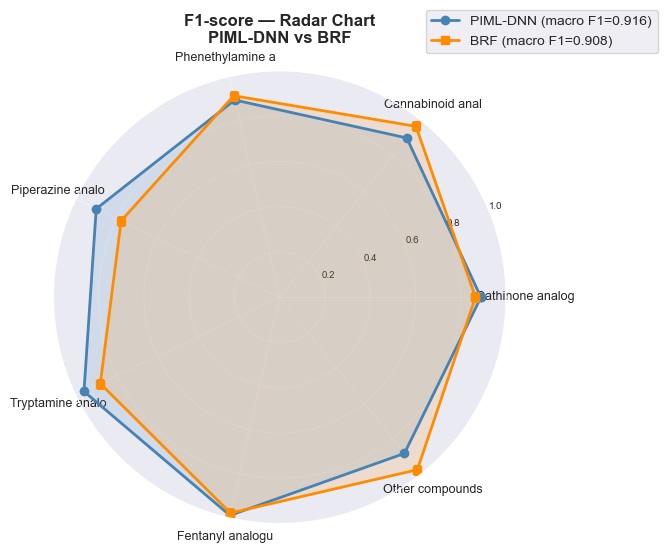

In [34]:
"""
Physics-Informed DNN v4 — versione bilanciata
=============================================
v2 overfittava  (gap +10-16%): rete 256→128→64, dropout 0.4
v3 underfittava (gap -20-26%): rete 128→64→32, dropout 0.5

Soluzione: punto di equilibrio
  - Rete: 256→128→64  (come v2)
  - Dropout: 0.4      (come v2)
  - Feature selection (da v3) → toglie le feature costanti/rumore
  - Mixup alpha ridotto: 0.1   (meno aggressivo)
  - Weight decay: 5e-4         (tra v2 1e-3 e v1 1e-4)

Target: gap train-val tra 0% e 8%
"""

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import classification_report
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings("ignore")

import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_fscore_support
from imblearn.ensemble import BalancedRandomForestClassifier
os.makedirs('plots', exist_ok=True)
COLORS = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B3','#937860','#DA8BC3']


DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

LEGENDS = {
    0: "Cathinone analogues",      1: "Cannabinoid analogues",
    2: "Phenethylamine analogues", 3: "Piperazine analogues",
    4: "Tryptamine analogues",     5: "Fentanyl analogues",
    6: "Other compounds",
}

CLASS_NAMES = list(LEGENDS.values())

# ─────────────────────────────────────────────────────────────────────────────
# 1. FEATURE SELECTION  (da v3, invariata)
# ─────────────────────────────────────────────────────────────────────────────

PHYSICS_MZ = [
    77, 91, 105,                                        # universali
    119, 121, 134, 148, 162, 176,                       # Cathinone
    55, 69, 83, 97, 111, 125, 144, 214, 250, 310, 340, 354, 368,  # Cannabinoid
    44, 58, 135, 150, 164, 178,                         # Phenethylamine
    71, 84, 98, 112, 154, 161, 168,                     # Piperazine
    103, 116, 130, 143, 159, 160, 174,                  # Tryptamine
    132, 146, 188, 202, 245, 260,                       # Fentanyl
]

def physics_guided_feature_selection(X: np.ndarray, y: np.ndarray,
                                      k_statistical: int = 100) -> np.ndarray:
    selector = SelectKBest(f_classif, k=k_statistical)
    selector.fit(X, y)
    stat_mask = selector.get_support()
    phys_mask = np.zeros(600, dtype=bool)
    for mz in PHYSICS_MZ:
        if 1 <= mz <= 600:
            phys_mask[mz - 1] = True
    combined = stat_mask | phys_mask
    print(f"  Feature selezionate: {combined.sum()} / 600 "
          f"(stat: {stat_mask.sum()}, physics-only: {(phys_mask & ~stat_mask).sum()})")
    return combined


# ─────────────────────────────────────────────────────────────────────────────
# 2. PHYSICS FEATURES  (invariate)
# ─────────────────────────────────────────────────────────────────────────────

def extract_physics_features(spectra: np.ndarray, mz_range: np.ndarray) -> np.ndarray:
    feats = []
    for spec in spectra:
        pm = spec > 1.0
        mz_p, int_p = mz_range[pm], spec[pm]
        if len(mz_p) == 0:
            feats.append([0.0] * 8); continue
        bpm   = mz_range[np.argmax(spec)] / 600.0
        nf    = len(mz_p) / 600.0
        cen   = np.sum(mz_p * int_p) / (np.sum(int_p) + 1e-8) / 600.0
        flm   = spec[mz_range <= 200].sum() / (spec.sum() + 1e-8)
        fhm   = spec[mz_range >= 300].sum() / (spec.sum() + 1e-8)
        std   = np.sqrt(np.sum(int_p * (mz_p - cen*600)**2) / (np.sum(int_p)+1e-8)) / 600.0
        m77   = spec[76] / 100.0
        m91   = spec[90] / 100.0
        feats.append([bpm, nf, cen, flm, fhm, std, m77, m91])
    return np.array(feats, dtype=np.float32)


# ─────────────────────────────────────────────────────────────────────────────
# 3. PHYSICS PRIOR sulle feature selezionate
# ─────────────────────────────────────────────────────────────────────────────

def build_physics_prior_masked(feature_mask: np.ndarray) -> torch.Tensor:
    prior = np.ones((7, 600), dtype=np.float32)
    def boost(ci, peaks, w=5.0, width=3):
        for mz in peaks:
            prior[ci, max(0,mz-1-width):min(600,mz-1+width+1)] += w
    boost(0, [77,91,105,119,121,134,148,162,176], w=6.0)
    boost(1, [55,69,83,97,111,125,144,214,250,310,340,354,368], w=6.0)
    boost(2, [44,58,77,91,105,121,135,150,164,178], w=6.0)
    boost(3, [58,71,84,98,112,154,161,168,176], w=6.0)
    boost(4, [77,103,116,130,143,144,159,160,174], w=6.0)
    boost(5, [77,105,132,146,188,202,245,260], w=6.0)
    prior = prior / prior.max(axis=1, keepdims=True)
    return torch.tensor(prior[:, feature_mask])


# ─────────────────────────────────────────────────────────────────────────────
# 4. ARCHITETTURA  — 256→128→64, dropout 0.4  (punto di equilibrio)
# ─────────────────────────────────────────────────────────────────────────────

class PhysicsGate(nn.Module):
    def __init__(self, n_feat, n_cls, prior):
        super().__init__()
        self.register_buffer("prior", prior)
        self.scale = nn.Parameter(torch.ones(n_cls, n_feat))
    def forward(self, x, cw):
        mask = (cw.unsqueeze(-1) * (self.prior * torch.sigmoid(self.scale)).unsqueeze(0)).sum(1)
        return x * mask


class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.4):
        super().__init__()
        self.block = nn.Sequential(
            nn.Linear(dim,dim), nn.BatchNorm1d(dim), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(dim,dim), nn.BatchNorm1d(dim),
        )
        self.relu = nn.ReLU()
    def forward(self, x):
        return self.relu(x + self.block(x))


class PhysicsInformedDNN(nn.Module):
    """
    Input: ~125 feature selezionate
    Encoder: 256 → 128 → 64  con residual blocks
    Dropout: 0.4
    Parametri attesi: ~200k
    """
    def __init__(self, n_features, n_classes=7, n_phys=8, prior=None, dropout=0.4):
        super().__init__()
        self.pre_enc = nn.Sequential(
            nn.Linear(n_features, 64), nn.ReLU(), nn.Dropout(dropout),
            nn.Linear(64, n_classes), nn.Softmax(dim=-1),
        )
        self.gate = PhysicsGate(n_features, n_classes, prior)
        self.proj = nn.Sequential(
            nn.Linear(n_features, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(dropout)
        )
        self.r1 = ResidualBlock(256, dropout)
        self.d1 = nn.Sequential(nn.Linear(256,128), nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(dropout))
        self.r2 = ResidualBlock(128, dropout)
        self.d2 = nn.Sequential(nn.Linear(128, 64), nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(dropout))
        self.r3 = ResidualBlock(64, dropout)
        self.clf  = nn.Sequential(nn.Linear(64,32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, n_classes))
        self.phys = nn.Sequential(nn.Linear(64,32), nn.ReLU(), nn.Dropout(dropout), nn.Linear(32, n_phys))

    def forward(self, x):
        pre = self.pre_enc(x)
        h   = self.gate(x, pre)
        h   = self.proj(h)
        h   = self.r1(h); h = self.d1(h)
        h   = self.r2(h); h = self.d2(h)
        h   = self.r3(h)
        return self.clf(h), self.phys(h), pre

    def predict_with_uncertainty(self, x, n_samples=50):
        self.train()
        preds = []
        with torch.no_grad():
            for _ in range(n_samples):
                logits, _, _ = self.forward(x)
                preds.append(torch.softmax(logits, -1))
        self.eval()
        p = torch.stack(preds)
        return p.mean(0), p.std(0)


# ─────────────────────────────────────────────────────────────────────────────
# 5. LOSS + MIXUP  (alpha ridotto a 0.1)
# ─────────────────────────────────────────────────────────────────────────────

def mixup(X, y, P, alpha=0.1):
    if alpha <= 0:
        return X, y, y, 1.0, P
    lam = np.random.beta(alpha, alpha)
    idx = torch.randperm(X.size(0), device=X.device)
    return lam*X+(1-lam)*X[idx], y, y[idx], lam, lam*P+(1-lam)*P[idx]


class PhysicsInformedLoss(nn.Module):
    def __init__(self, lp=0.3, lc=0.1, ls=0.05):
        super().__init__()
        self.lp = lp; self.lc = lc
        self.ce  = nn.CrossEntropyLoss(label_smoothing=ls, reduction="none")
        self.mse = nn.MSELoss()
        self.kl  = nn.KLDivLoss(reduction="batchmean")
    def forward(self, logits, ya, yb, lam, pp, pt, pre):
        Lce = (lam*self.ce(logits,ya) + (1-lam)*self.ce(logits,yb)).mean()
        Lp  = self.mse(pp, pt)
        Lco = self.kl(torch.log(torch.softmax(logits,-1)+1e-8), pre.detach())
        return Lce + self.lp*Lp + self.lc*Lco, {"L_ce":Lce.item(),"L_phys":Lp.item(),"L_consist":Lco.item()}


# ─────────────────────────────────────────────────────────────────────────────
# 6. TRAINING LOOP
# ─────────────────────────────────────────────────────────────────────────────

def train_epoch(model, loader, crit, opt, alpha=0.1):
    model.train()
    tl, cor, tot = 0, 0, 0
    for Xb, yb, Pb in loader:
        Xm, ya, yb2, lam, Pm = mixup(Xb, yb, Pb, alpha)
        opt.zero_grad()
        lg, pp, pre = model(Xm)
        loss, _ = crit(lg, ya, yb2, lam, pp, Pm, pre)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        opt.step()
        n = len(yb); tl += loss.item()*n
        cor += (lg.argmax(-1)==ya).sum().item(); tot += n
    return tl/tot, cor/tot


@torch.no_grad()
def eval_epoch(model, loader, crit):
    model.eval()
    tl, cor, tot = 0, 0, 0
    for Xb, yb, Pb in loader:
        lg, pp, pre = model(Xb)
        loss, _ = crit(lg, yb, yb, 1.0, pp, Pb, pre)
        tl += loss.item()*len(yb)
        cor += (lg.argmax(-1)==yb).sum().item(); tot += len(yb)
    return tl/tot, cor/tot


def train_fold(model, tr, va, epochs=150, patience=25, path="best.pt"):
    crit  = PhysicsInformedLoss()
    opt   = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=5e-4)  # FIX: 5e-4
    sched = optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, T_0=30, T_mult=2)
    best_va, best_tr, pat_ctr = 0.0, 0.0, 0
    for ep in range(1, epochs+1):
        tr_loss, tr_acc = train_epoch(model, tr, crit, opt, alpha=0.0)
        va_loss, va_acc = eval_epoch(model, va, crit)
        sched.step()
        if tr_acc > best_tr: best_tr = tr_acc
        if va_acc > best_va:
            best_va = va_acc; torch.save(model.state_dict(), path); pat_ctr = 0
        else:
            pat_ctr += 1
        if pat_ctr >= patience: break
    model.load_state_dict(torch.load(path))
    return best_va, best_tr

#print(f"{fold:>5} {bva*100:>7.2f}% {btr*100:>9.2f}% {(btr-bva)*100:>+7.2f}% {nf:>8}")
# ─────────────────────────────────────────────────────────────────────────────
# 7. MAIN
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":
    import pandas as pd

    nps      = pd.read_csv("datasetNPS/1-s2.0-S2468170923000358-mmc1.csv")
    mz_range = np.arange(1, 601)
    spectra  = nps[mz_range.astype(str)].values.astype(np.float32)
    labels   = nps["label"].values
    mv       = spectra.max(axis=1, keepdims=True); mv[mv==0] = 1
    spectra  = spectra / mv * 100.0
    phys_f   = extract_physics_features(spectra, mz_range)

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    fold_results, all_p, all_t = [], [], []

    print(f"{'Fold':>5} {'ValAcc':>8} {'TrainAcc':>10} {'Gap':>8} {'N feat':>8}")
    print("-" * 45)

    for fold, (tri, vai) in enumerate(skf.split(spectra, labels), 1):
        Xtr0, Xva = spectra[tri], spectra[vai]
        ytr0, yva = labels[tri],  labels[vai]
        Ptr0, Pva = phys_f[tri],  phys_f[vai]

        # SMOTE
        XP = np.concatenate([Xtr0, Ptr0], axis=1)
        XP_r, ytr = SMOTE(random_state=42).fit_resample(XP, ytr0)
        Xtr, Ptr = XP_r[:,:600], XP_r[:,600:]

        # Feature selection (no leakage)
        mask = physics_guided_feature_selection(Xtr, ytr)
        Xtr_s_raw, Xva_s_raw = Xtr[:,mask], Xva[:,mask]
        nf = mask.sum()

        # Scaling
        scX = StandardScaler(); scP = StandardScaler()
        Xtr_s = scX.fit_transform(Xtr_s_raw).astype(np.float32)
        Xva_s = scX.transform(Xva_s_raw).astype(np.float32)
        Ptr_s = scP.fit_transform(Ptr).astype(np.float32)
        Pva_s = scP.transform(Pva).astype(np.float32)

        def tt(a): return torch.tensor(a, dtype=torch.float32).to(DEVICE)
        def tl(a): return torch.tensor(a, dtype=torch.long).to(DEVICE)

        tr_ld = DataLoader(TensorDataset(tt(Xtr_s),tl(ytr),tt(Ptr_s)), batch_size=32, shuffle=True)
        va_ld = DataLoader(TensorDataset(tt(Xva_s),tl(yva),tt(Pva_s)), batch_size=32)

        prior = build_physics_prior_masked(mask).to(DEVICE)
        model = PhysicsInformedDNN(nf, prior=prior, dropout=0.4).to(DEVICE)

        bva, btr = train_fold(model, tr_ld, va_ld,
                              epochs=150, patience=25,
                              path=f"model/v4_fold_{fold}.pt")

        gap = (btr - bva) * 100
        print(f"{fold:>5} {bva*100:>7.2f}% {btr*100:>9.2f}% {gap:>+7.2f}% {nf:>8}")
        fold_results.append(bva)

        # salva variabili fold 4 per i grafici
        if fold == 4:
            fold4 = dict(
                model=model, mask=mask,
                Xtr_s=Xtr_s, ytr=ytr,
                Xva_s=Xva_s, yva=yva,
                Pva_s=Pva_s,
            )

        model.eval()
        with torch.no_grad():
            for Xb, yb, _ in va_ld:
                lg, _, _ = model(Xb)
                all_p.extend(lg.argmax(-1).cpu().numpy())
                all_t.extend(yb.cpu().numpy())

    print(f"\nMean CV Accuracy: {np.mean(fold_results)*100:.2f}% ± {np.std(fold_results)*100:.2f}%")
    print("\n=== Classification Report (aggregato 5-fold) ===")
    print(classification_report(all_t, all_p, target_names=list(LEGENDS.values())))
    bf = int(np.argmax(fold_results)) + 1
    print(f"Miglior fold: {bf} ({max(fold_results)*100:.2f}%) → model/v4_fold_{bf}.pt")
    # ── Predizioni deterministiche sul fold 4 ────────────────────────────────
    m      = fold4['model'];  m.eval()
    Xva_t  = torch.tensor(fold4['Xva_s'], dtype=torch.float32).to(DEVICE)
    yva    = fold4['yva']
    mz_sel = mz_range[fold4['mask']]

    all_logits, all_true = [], []
    with torch.no_grad():
        for i in range(0, len(Xva_t), 32):
            lg, _, _ = m(Xva_t[i:i+32])
            all_logits.append(lg.cpu())
            all_true.extend(yva[i:i+32])
    all_logits = torch.cat(all_logits).numpy()
    all_probs  = torch.softmax(torch.tensor(all_logits), dim=-1).numpy()
    all_preds  = all_logits.argmax(axis=1)
    all_true   = np.array(all_true)
    print(f'\nFold 4 accuracy: {(all_preds==all_true).mean()*100:.2f}%')

    # ── CONFUSION MATRIX ─────────────────────────────────────────────────────
    cm      = confusion_matrix(all_true, all_preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1)[:, None]
    fig, axes = plt.subplots(1, 2, figsize=(18, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, ax=axes[0], cbar_kws={'shrink': 0.8})
    axes[0].set_title('Confusion Matrix — conteggi', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('True Label'); axes[0].set_xlabel('Predicted Label')
    plt.setp(axes[0].get_xticklabels(), rotation=40, ha='right', fontsize=9)
    plt.setp(axes[0].get_yticklabels(), rotation=0,  fontsize=9)
    sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
                linewidths=0.5, vmin=0, vmax=1, ax=axes[1], cbar_kws={'shrink': 0.8})
    axes[1].set_title('Confusion Matrix — normalizzata', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('True Label'); axes[1].set_xlabel('Predicted Label')
    plt.setp(axes[1].get_xticklabels(), rotation=40, ha='right', fontsize=9)
    plt.setp(axes[1].get_yticklabels(), rotation=0,  fontsize=9)
    plt.suptitle('PIML-DNN — Fold 4', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plots/confusion_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── ROC CURVES ───────────────────────────────────────────────────────────
    y_bin = label_binarize(all_true, classes=np.arange(7))
    fpr, tpr, roc_auc = {}, {}, {}
    for i in range(7):
        fpr[i], tpr[i], _ = roc_curve(y_bin[:, i], all_probs[:, i])
        roc_auc[i]        = auc(fpr[i], tpr[i])
    fpr['micro'], tpr['micro'], _ = roc_curve(y_bin.ravel(), all_probs.ravel())
    roc_auc['micro']              = auc(fpr['micro'], tpr['micro'])

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    for i in range(7):
        axes[0].plot(fpr[i], tpr[i], color=COLORS[i], lw=2,
                     label=f'{CLASS_NAMES[i]} (AUC={roc_auc[i]:.3f})')
    axes[0].plot([0,1],[0,1], 'k--', lw=1, alpha=0.5)
    axes[0].set_xlim([0,1]); axes[0].set_ylim([0,1.02])
    axes[0].set_xlabel('False Positive Rate'); axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title('ROC Curves — per classe (OvR)', fontweight='bold')
    axes[0].legend(loc='lower right', fontsize=8); axes[0].grid(True, alpha=0.3)
    aucs = [roc_auc[i] for i in range(7)]
    bars = axes[1].barh(CLASS_NAMES, aucs, color=COLORS, edgecolor='white', height=0.6)
    axes[1].set_xlim([0.7, 1.01]); axes[1].set_xlabel('AUC')
    axes[1].set_title(f'AUC per classe  |  Micro-avg={roc_auc["micro"]:.3f}', fontweight='bold')
    axes[1].axvline(roc_auc['micro'], color='black', lw=1.5, linestyle='--', label='Micro avg')
    for bar, val in zip(bars, aucs):
        axes[1].text(val+0.002, bar.get_y()+bar.get_height()/2,
                     f'{val:.3f}', va='center', fontsize=9)
    axes[1].grid(True, alpha=0.3, axis='x'); axes[1].legend(fontsize=9)
    plt.suptitle('PIML-DNN — ROC Analysis', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plots/roc_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── PHYSICS GATE WEIGHTS ─────────────────────────────────────────────────
    with torch.no_grad():
        prior_np   = m.gate.prior.cpu().numpy()
        learned_np = torch.sigmoid(m.gate.scale).cpu().numpy()
        effect_np  = prior_np * learned_np

    fig, axes = plt.subplots(7, 3, figsize=(20, 22))
    col_titles = ['Prior fisico (fisso)', 'Scale appreso', 'Gate effettivo']
    col_colors = ['steelblue', 'darkorange', 'seagreen']
    for i, cls in enumerate(CLASS_NAMES):
        for j, (data, col) in enumerate(zip([prior_np[i], learned_np[i], effect_np[i]], col_colors)):
            ax = axes[i, j]
            ax.fill_between(mz_sel, data, alpha=0.65, color=col)
            ax.plot(mz_sel, data, color=col, lw=0.8)
            ax.set_ylim(0, 1.15); ax.set_xlim(mz_sel[0], mz_sel[-1])
            if i == 0: ax.set_title(col_titles[j], fontsize=10, fontweight='bold', color=col)
            if j == 0: ax.set_ylabel(cls, fontsize=8)
            ax.set_xlabel('m/z', fontsize=7); ax.tick_params(labelsize=6)
            ax.grid(True, alpha=0.2)
    plt.suptitle('PhysicsGate: prior fisso → scale appreso → gate effettivo',
                 fontsize=12, fontweight='bold', y=1.002)
    plt.tight_layout()
    plt.savefig('plots/physics_gate_weights.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── TOP 10 m/z PER CLASSE ────────────────────────────────────────────────
    fig, axes = plt.subplots(2, 4, figsize=(20, 8))
    axes = axes.flatten()
    for i, cls in enumerate(CLASS_NAMES):
        top_idx = np.argsort(effect_np[i])[::-1][:10]
        top_mz  = mz_sel[top_idx]
        top_val = effect_np[i][top_idx]
        bars = axes[i].bar(range(10), top_val, color=COLORS[i], edgecolor='white', alpha=0.85)
        axes[i].set_xticks(range(10))
        axes[i].set_xticklabels([f'm/z {x}' for x in top_mz], rotation=45, ha='right', fontsize=8)
        axes[i].set_title(cls, fontsize=9, fontweight='bold', color=COLORS[i])
        axes[i].set_ylabel('Gate weight', fontsize=8); axes[i].set_ylim(0, 1.1)
        axes[i].grid(True, alpha=0.3, axis='y')
        for bar, val in zip(bars, top_val):
            axes[i].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.02,
                         f'{val:.2f}', ha='center', fontsize=7)
    axes[7].remove()
    plt.suptitle('Top 10 m/z per classe — PhysicsGate effettivo', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plots/top_mz_per_class.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── UNCERTAINTY (MC DROPOUT) ─────────────────────────────────────────────
    mean_probs, std_probs = m.predict_with_uncertainty(Xva_t, n_samples=100)
    mean_np      = mean_probs.cpu().numpy()
    std_np       = std_probs.cpu().numpy()
    mc_preds     = mean_np.argmax(axis=1)
    sample_unc   = std_np.mean(axis=1)
    correct_mask = (mc_preds == all_true)
    print(f'MC Dropout accuracy: {correct_mask.mean()*100:.2f}%')
    print(f'Uncertainty corretti: {sample_unc[correct_mask].mean():.4f}')
    print(f'Uncertainty errati:   {sample_unc[~correct_mask].mean():.4f}')

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].hist(sample_unc[correct_mask],  bins=25, alpha=0.7, color='steelblue',
                 label=f'Corretti (n={correct_mask.sum()})', density=True)
    axes[0].hist(sample_unc[~correct_mask], bins=25, alpha=0.7, color='tomato',
                 label=f'Errati (n={(~correct_mask).sum()})', density=True)
    axes[0].axvline(sample_unc[correct_mask].mean(),  color='steelblue', lw=2, linestyle='--')
    axes[0].axvline(sample_unc[~correct_mask].mean(), color='tomato',    lw=2, linestyle='--')
    axes[0].set_xlabel('Uncertainty (std MC)'); axes[0].set_ylabel('Density')
    axes[0].set_title('Uncertainty: Corretti vs Errati', fontweight='bold')
    axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3)
    unc_by_class = [sample_unc[all_true == i] for i in range(7)]
    bp = axes[1].boxplot(unc_by_class, patch_artist=True,
                         medianprops={'color': 'black', 'lw': 2})
    for patch, color in zip(bp['boxes'], COLORS):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    axes[1].set_xticks(range(1, 8))
    axes[1].set_xticklabels([c[:12] for c in CLASS_NAMES], rotation=35, ha='right', fontsize=8)
    axes[1].set_ylabel('Uncertainty (std MC)')
    axes[1].set_title('Uncertainty per classe', fontweight='bold')
    axes[1].grid(True, alpha=0.3, axis='y')
    thresholds = np.linspace(sample_unc.min(), sample_unc.max(), 60)
    sel_accs, covs = [], []
    for t in thresholds:
        mk = sample_unc <= t
        if mk.sum() > 0:
            sel_accs.append(correct_mask[mk].mean() * 100)
            covs.append(mk.mean() * 100)
    full_acc = correct_mask.mean() * 100
    axes[2].plot(covs, sel_accs, color='steelblue', lw=2.5)
    axes[2].axhline(full_acc, color='gray', lw=1.5, linestyle='--',
                    label=f'Full accuracy ({full_acc:.1f}%)')
    axes[2].fill_between(covs, sel_accs, full_acc,
                         where=[a > full_acc for a in sel_accs],
                         alpha=0.15, color='steelblue', label='Guadagno da selezione')
    axes[2].set_xlabel('Coverage (%)'); axes[2].set_ylabel('Accuracy (%)')
    axes[2].set_title('Selective Prediction', fontweight='bold')
    axes[2].legend(fontsize=9); axes[2].grid(True, alpha=0.3)
    plt.suptitle('Uncertainty Quantification — MC Dropout (100 samples)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plots/uncertainty_analysis.png', dpi=150, bbox_inches='tight')
    plt.show()

    # ── CONFRONTO PIML-DNN vs BRF ────────────────────────────────────────────
    brf = BalancedRandomForestClassifier(n_estimators=100, random_state=42)
    brf.fit(fold4['Xtr_s'], fold4['ytr'])
    brf_preds = brf.predict(fold4['Xva_s'])
    print(f'BRF accuracy: {(brf_preds==yva).mean()*100:.2f}%')

    p_dnn, r_dnn, f_dnn, _ = precision_recall_fscore_support(all_true, all_preds, average=None)
    p_brf, r_brf, f_brf, _ = precision_recall_fscore_support(yva,      brf_preds, average=None)

    fig, axes = plt.subplots(1, 3, figsize=(20, 6))
    x = np.arange(7); width = 0.35
    for ax, (dnn_v, brf_v, metric) in zip(axes, [
        (p_dnn, p_brf, 'Precision'), (r_dnn, r_brf, 'Recall'), (f_dnn, f_brf, 'F1-score')
    ]):
        ax.bar(x - width/2, dnn_v, width, label='PIML-DNN',
               color='steelblue', alpha=0.85, edgecolor='white')
        ax.bar(x + width/2, brf_v, width, label='BRF',
               color='darkorange', alpha=0.85, edgecolor='white')
        ax.set_xticks(x)
        ax.set_xticklabels([c[:14] for c in CLASS_NAMES], rotation=40, ha='right', fontsize=8)
        ax.set_ylim(0, 1.15); ax.set_ylabel(metric)
        ax.set_title(f'{metric} per classe', fontweight='bold')
        ax.legend(fontsize=9); ax.grid(True, alpha=0.3, axis='y')
        ax.axhline(0.9, color='gray', lw=1, linestyle=':', alpha=0.5)
        for xi, (dv, bv) in enumerate(zip(dnn_v, brf_v)):
            ax.text(xi, max(dv, bv)+0.04, f'{dv-bv:+.2f}', ha='center', fontsize=7,
                    color='green' if dv > bv else 'red', fontweight='bold')
    plt.suptitle('PIML-DNN vs BRF  (verde=DNN migliore, rosso=BRF migliore)',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('plots/comparison_dnn_vs_brf.png', dpi=150, bbox_inches='tight')
    plt.show()

    # Radar chart
    macro_dnn = f_dnn.mean(); macro_brf = f_brf.mean()
    angles = np.linspace(0, 2*np.pi, 7, endpoint=False).tolist() + [0]
    dnn_r  = list(f_dnn) + [f_dnn[0]]
    brf_r  = list(f_brf) + [f_brf[0]]
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    ax.plot(angles, dnn_r, 'o-', lw=2, color='steelblue',
            label=f'PIML-DNN (macro F1={macro_dnn:.3f})')
    ax.fill(angles, dnn_r, alpha=0.15, color='steelblue')
    ax.plot(angles, brf_r, 's-', lw=2, color='darkorange',
            label=f'BRF (macro F1={macro_brf:.3f})')
    ax.fill(angles, brf_r, alpha=0.15, color='darkorange')
    ax.set_thetagrids(np.degrees(angles[:-1]), [c[:16] for c in CLASS_NAMES], fontsize=9)
    ax.set_ylim(0, 1); ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(['0.2','0.4','0.6','0.8','1.0'], fontsize=7)
    ax.set_title('F1-score — Radar Chart\nPIML-DNN vs BRF',
                 fontsize=12, fontweight='bold', pad=20)
    ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig('plots/radar_chart.png', dpi=150, bbox_inches='tight')
    plt.show()

In [33]:
%pip install windrose

Note: you may need to restart the kernel to use updated packages.
